In [1]:
import pandas as pd
import numpy as np
import scipy.io as scio
import mat73
import os
import sys
from tqdm import tqdm
from collections import defaultdict
import openpyxl 
import dill
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
import importlib
import helper_function as hf
importlib.reload(hf)
# import plotting_functions as pf
# importlib.reload(pf)

2026-04-09 15:41:14,935 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-04-09 15:41:14,943 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2026-04-09 15:41:14,945 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



ModuleNotFoundError: No module named 'plotting_functions'

In [3]:
#IMPORT data from matlab files
dd= pd.read_csv(r"Z:\zimmer\jalaja\imaging\newline\cleaned\for_BundleNet\deltaFoF_alldataset.csv", delimiter=',',parse_dates=True)
dd.columns=dd.columns.str.strip("''")
dd

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
0,0.387170,0.097740,0.312340,0.145770,NaN,0.95588,-0.11433,0.003151,1.35830,0.554600,...,0.073543,0.12440,NaN,NaN,0.62955,0.098488,0.015532,2,1,1
1,0.418530,0.069665,0.267290,0.128760,NaN,0.92111,-0.13575,-0.015684,1.27280,0.570670,...,0.046784,0.12474,NaN,NaN,0.61028,0.084541,0.013973,2,1,1
2,0.448780,0.051929,0.239980,0.105750,NaN,0.87986,-0.14115,-0.037594,1.16260,0.580160,...,0.033031,0.12504,NaN,NaN,0.57180,0.079309,-0.002591,2,1,1
3,0.477770,0.045791,0.232590,0.076009,NaN,0.83133,-0.12856,-0.062951,1.02460,0.582280,...,0.033870,0.12532,NaN,NaN,0.51179,0.083855,-0.035988,2,1,1
4,0.475250,0.053608,0.209490,0.073328,NaN,0.85503,-0.13928,-0.052906,0.95813,0.536360,...,0.039577,0.13207,NaN,NaN,0.51291,0.082970,-0.007096,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85045,-0.100090,-0.123270,-0.091191,-0.339340,-0.35703,-0.48824,-0.22803,NaN,-0.19723,-0.132620,...,-0.126310,NaN,-0.052055,0.103360,-0.18571,-0.098487,0.198120,2,1,9
85046,-0.086111,-0.106290,-0.089964,-0.339710,-0.34738,-0.48779,-0.20283,NaN,-0.19967,-0.128080,...,-0.127810,NaN,-0.058894,0.097431,-0.19207,-0.100030,0.206260,2,1,9
85047,-0.089498,-0.134590,-0.097088,-0.355450,-0.33665,-0.49817,-0.20000,NaN,-0.19820,-0.117480,...,-0.114520,NaN,-0.066565,0.095080,-0.20473,-0.103260,0.214000,2,1,9
85048,-0.090512,-0.149300,-0.092970,-0.346930,-0.33888,-0.49830,-0.20349,NaN,-0.20218,-0.108090,...,-0.120090,NaN,-0.053817,0.091680,-0.20745,-0.111210,0.203250,2,1,9


In [4]:
#Normalize scaling
fps = 5
X=dd.drop({'target','state','group'},axis=1)

scaled_datasets_X = []

for n in range(1, 10):
# for n in range(0, 9):
    # robust_scaler=RobustScaler()
    robust_scaler=RobustScaler(with_centering=False, with_scaling=True, quantile_range=(5, 95))
    # scaled_data_X = robust_scaler.fit_transform(X.loc[n*9450:(n+1)*9450-1,:])
    # scaled_data_X = robust_scaler.fit_transform(X.loc[n*9450:(n*9450)+(450*fps),:])
    group_data=X[dd['group'] == n]
    scaled_data_X =robust_scaler.fit_transform(group_data)
    scaled_datasets_X.append(scaled_data_X)

# Concatenate scaled datasets from each group
scaled_X_within_group = np.concatenate(scaled_datasets_X)

# Scale across all groups
scaled_X_across_groups = robust_scaler.fit_transform(scaled_X_within_group)
scaled_X=pd.DataFrame(data=scaled_X_across_groups,columns=X.columns) 


normalized_data = pd.DataFrame(data=np.c_[scaled_X, dd['target'],dd['state'],dd['group']],columns=dd.columns)
normalized_data.columns=normalized_data.columns.str.strip("''")

C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\num

In [28]:
def z_score_df(df):
    """
    Z-scores each column of a dataframe.

    Parameters:
    df (pd.DataFrame): Dataframe with numerical columns to be z-scored.

    Returns:
    pd.DataFrame: Dataframe with z-scored columns.
    """
    return (df - df.mean()) / df.std()

In [6]:
#Imputing the missing values using ppca, this computation takes a while on server, if the connect is poor, skip to the next step
dk=hf.impute_missing_values_in_dataframe(normalized_data.drop({'target','state','group'}, axis=1))
df = pd.DataFrame(data=np.c_[dk, dd['target'],dd['state'],dd['group']],columns=dd.columns)

C:\Users\Jalaja Madhusudhanan\AppData\Roaming\Python\Python311\site-packages\ppca\_ppca.py:82: RuntimeWarning: divide by zero encountered in log
  det = np.log(np.linalg.det(Sx))


In [5]:
#sometimes the server connection is poor that it get stuck at this step and can not proceed :( In that case, I skip and use the saved version of the output.
df=pd.read_csv("/lisc/data/scratch/neurobiology/zimmer/jalaja/imaging/newline/cleaned/for_BundleNet/deltaFoF_alldataset_normalized_imputed.csv",index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '/lisc/data/scratch/neurobiology/zimmer/jalaja/imaging/newline/cleaned/for_BundleNet/deltaFoF_alldataset_normalized_imputed.csv'

In [27]:
imp=SimpleImputer(strategy='mean')
dk=imp.fit_transform(dd.drop({'target','state','group'}, axis=1))
df = pd.DataFrame(data=np.c_[dk, dd['target'],dd['state'],dd['group']],columns=dd.columns)

In [29]:
df=z_score_df(dd)

In [28]:
# create triggered traces
    # Parameters
interval_start = 450 # start at 390 seconds
interval_step = 90  # interval of 90 seconds
slice_duration = 60  # slice the prestimulus 60 seconds
stimulus_period=30
fps = 5  # frames per second

# Create the new sliced DataFrame
sliced_df , triggered_df= hf.create_sliced_dataframe(df, interval_start, interval_step, slice_duration,stimulus_period, fps)
print(triggered_df)

           AIBL      AIBR      AIZL       ALA      ALNL      ALNR      AQR  \
1950  -0.070416 -0.062925  0.031579  0.025764 -0.000003 -0.040916 -0.19563   
1951  -0.082084 -0.054971  0.049034  0.035689 -0.000003 -0.046363 -0.19378   
1952  -0.099611 -0.064666  0.080167  0.041408 -0.000003 -0.036690 -0.18160   
1953  -0.108990 -0.061819  0.069385  0.037602 -0.000003 -0.038526 -0.17452   
1954  -0.112870 -0.061294  0.059709  0.025974 -0.000003 -0.041268 -0.17183   
...         ...       ...       ...       ...       ...       ...      ...   
84745 -0.057389 -0.062877 -0.131940 -0.362340 -0.297030 -0.518810  0.17351   
84746 -0.056433 -0.062553 -0.140750 -0.362070 -0.297890 -0.512270  0.16168   
84747 -0.076061 -0.093392 -0.127570 -0.355730 -0.296380 -0.507070  0.17590   
84748 -0.085367 -0.093561 -0.130170 -0.360850 -0.287420 -0.521020  0.15919   
84749 -0.088727 -0.080994 -0.139230 -0.369430 -0.275370 -0.540510  0.13119   

           AS10      ASKL      ASKR  ...     URYVR      VA01   

In [29]:
# Drop rows where 'target' is 2
triggered_df_forPLS = triggered_df[triggered_df['target'] != 2]

In [30]:
# Lte's make a slice of -5 second windoe for LDA
interval_start = 450 # start at 390 seconds
interval_step = 90  # interval of 90 seconds
slice_duration = 5  # slice the prestimulus 60 seconds
stimulus_period=30
fps = 5  # frames per second

# Create the new sliced DataFrame
sliced_df , triggered_df= hf.create_sliced_dataframe(df, interval_start, interval_step, slice_duration,stimulus_period, fps)
print(triggered_df)

           AIBL      AIBR      AIZL       ALA      ALNL      ALNR      AQR  \
2225  -0.117910 -0.069498  0.022065 -0.072323 -0.000003 -0.062762 -0.18869   
2226  -0.121870 -0.071546  0.039768 -0.082603 -0.000003 -0.061947 -0.17095   
2227  -0.097389 -0.066925  0.012867 -0.072275 -0.000003 -0.057102 -0.17527   
2228  -0.086414 -0.071966  0.024068 -0.056823 -0.000003 -0.064299 -0.18420   
2229  -0.082889 -0.080812  0.046413 -0.042358 -0.000003 -0.077071 -0.19442   
...         ...       ...       ...       ...       ...       ...      ...   
84745 -0.057389 -0.062877 -0.131940 -0.362340 -0.297030 -0.518810  0.17351   
84746 -0.056433 -0.062553 -0.140750 -0.362070 -0.297890 -0.512270  0.16168   
84747 -0.076061 -0.093392 -0.127570 -0.355730 -0.296380 -0.507070  0.17590   
84748 -0.085367 -0.093561 -0.130170 -0.360850 -0.287420 -0.521020  0.15919   
84749 -0.088727 -0.080994 -0.139230 -0.369430 -0.275370 -0.540510  0.13119   

           AS10      ASKL      ASKR  ...     URYVR      VA01   

In [31]:
df_pls=pd.DataFrame(data=sliced_df)
# Drop rows where 'target_vector' is 2
sliced_df_forPLS = df_pls[df_pls['target'] != 2]
pls_X=triggered_df_forPLS.drop({'target','state','group'},axis=1)
pls_x=sliced_df_forPLS.drop({'target','state','group'},axis=1)
motor_neurons={'DB01','DB02','DB07','VB01','VB02','AS10','DA01','DA07','DA09','VA01','VA11','VA12','VD13','target','state','group'}
exclude={'ASKR','BAGL','URXR','VB01','SMBDL','SIADL','AVAL','AIBL','SMDVL','RIML','RIMR','ALNL','SMDVR','DB02','RIVL','DA09','URYVR','AVAR','AQR','VA01','URYDL','AUAL','AVEL','DA07','IL2R','target','state','group'}
pls_x_nomotor=df_pls.drop(exclude,axis=1)
y=sliced_df_forPLS['target']
groups=sliced_df_forPLS['group']

In [15]:
from sklearn.cross_decomposition import PLSCanonical
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=3)
pls.fit(pls_x,y)

PLSRegression(n_components=3)

In [17]:
from sklearn.model_selection import StratifiedGroupKFold
lda = LinearDiscriminantAnalysis()
# cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=None)
cv= StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)
cv_scores=cross_val_score(lda,pls.transform(pls_x), y, scoring='accuracy', cv=cv, n_jobs=-1,groups=groups)
cv_scores.mean()

0.7936893630400607

In [15]:
after_pls_df=pd.DataFrame(data=np.c_[pls.transform(pls_X),triggered_df_forPLS['target'],triggered_df_forPLS['group'],triggered_df_forPLS['state']],columns=['PLS1','PLS2','PLS3','PLS4','PLS5','target','group','state'])

In [43]:
n=450
Y=after_pls_df['target']
PLS1_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS2_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS3_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS4_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS5_df = pd.DataFrame(index=range(117), columns=range(n+1))

for i in range(0,117):
    row_index = (i * n)
    PLS1_df.iloc[i, :-1] = after_pls_df.iloc[row_index:row_index + n, 0]
    PLS2_df.iloc[i, :-1] = after_pls_df.iloc[row_index:row_index + n, 1]
    PLS3_df.iloc[i, :-1] = after_pls_df.iloc[row_index:row_index + n, 2]
    


    PLS1_df.iloc[i, -1] = Y[row_index]  # Assign the last value of the window to the last column
    PLS2_df.iloc[i, -1] = Y[row_index]
    PLS3_df.iloc[i, -1] = Y[row_index]
   

In [34]:
from numpy import mean
from numpy import std
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import permutation_test_score
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")
def single_neuron_lda(df):
    dg = pd.DataFrame(index=df.columns.drop(['target','group']),columns=['mean_accuracy','std'])
    for neuron in df.columns.drop(['target','group']):
        print(neuron)
        ind_nan=df[neuron].isna()
        ind=ind_nan[ind_nan==False].index
        X=df[[neuron]].dropna()
        y =df.loc[ind,'target']
        groups=df.loc[ind,'group']
            
        # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        model= LinearDiscriminantAnalysis()
        #model= LogisticRegression()
        model.fit(X,y)
        # cv = RepeatedStratifiedKFold(n_splits=5, random_state=0)
        cv= StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)
        #cv=GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv=StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        # logo = LeaveOneGroupOut()
        # n_splits=logo.get_n_splits(X, y, groups)
        # cv=logo
        
        scores, perm_scores, pvalue = permutation_test_score(model, X, y, scoring="accuracy", cv=cv, groups=groups, n_permutations=1000)
        scores = cross_val_score(model, X, y, scoring="accuracy", cv=cv,groups=groups,n_jobs=1)
        print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))
        print(scores)
        m=(mean(scores))
        s=(std(scores))
        perm_mean_score=(mean(perm_scores))
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots()

        hist_data, bins, _ = ax.hist(perm_scores, bins=20, density=True, color="tab:purple")
        # Calculate the x-coordinates for the shaded region
        ax.errorbar(m, hist_data.max(), xerr=s, color="gray", lw=2, capsize=5)

        ax.axvline(m, ls="--", color="k")
        ax.axvline(perm_mean_score, ls="--", color="gray")
        score_label = f"Score on original\ndata: {m:.2f}\n(p-value: {pvalue:.3f})"
        ax.text(0.7, 10, score_label, fontsize=12)
        ax.set_xlabel("Accuracy score")
        _ = ax.set_ylabel("Probability density")
        plt.show()
        dg.loc[neuron, 'mean_accuracy'] = m
        dg.loc[neuron, 'std']=s
        dg.loc[neuron, 'perm_accuaracy'] = perm_mean_score
        dg.loc[neuron,'p-value']= pvalue
        
    return dg


In [33]:
avg_df = (
    sliced_df_forPLS.groupby(np.arange(len(sliced_df_forPLS)) // 25)
      .agg({
          **{c:'mean' for c in sliced_df_forPLS.columns if c not in ['target','group','state']},
          'target':'first',
          'group':'first'
      })
)

In [18]:
sliced_df_forPLS

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
2225,-0.158781,-0.240637,0.129054,-0.336950,-0.046410,-0.135181,-0.172677,0.021194,0.036245,-0.055331,...,0.118038,0.228508,0.025183,-0.035927,-0.005076,0.122304,-0.143502,1.0,1.0,1.0
2226,-0.164113,-0.247729,0.232596,-0.384845,-0.034134,-0.133425,-0.156442,-0.068859,0.030059,-0.048325,...,0.119247,0.260345,0.024212,-0.041451,-0.015300,0.168745,-0.144274,1.0,1.0,1.0
2227,-0.131146,-0.231728,0.075257,-0.336727,-0.038524,-0.122990,-0.160396,-0.053434,0.042988,0.016492,...,0.231925,0.217588,0.036845,-0.021114,0.000586,0.190680,-0.123086,1.0,1.0,1.0
2228,-0.116367,-0.249183,0.140769,-0.264736,-0.025848,-0.138491,-0.168568,-0.056528,-0.001383,0.040684,...,0.253156,0.224111,0.039309,-0.016533,0.013125,0.258903,-0.117277,1.0,1.0,1.0
2229,-0.111620,-0.279812,0.271461,-0.197345,-0.009782,-0.166000,-0.177921,-0.088591,-0.071430,0.040750,...,0.234839,0.255000,0.027897,-0.026983,0.020644,0.299263,-0.121478,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84595,-0.178135,-0.335060,-0.234720,-0.475655,-0.372221,-0.418581,-0.153378,0.130046,-0.152379,0.012007,...,-0.486713,-0.314476,-0.049692,0.215252,-0.368555,-0.480779,0.558112,0.0,1.0,9.0
84596,-0.178108,-0.332287,-0.210152,-0.473305,-0.364866,-0.414185,-0.151884,0.120974,-0.187023,0.013359,...,-0.427294,-0.314399,-0.085239,0.192820,-0.388587,-0.513600,0.548658,0.0,1.0,9.0
84597,-0.208563,-0.330841,-0.292698,-0.492498,-0.380524,-0.430553,-0.159555,0.096580,-0.234774,-0.076547,...,-0.291499,-0.312328,-0.168939,0.180599,-0.416012,-0.552122,0.597645,0.0,1.0,9.0
84598,-0.232825,-0.306455,-0.287665,-0.495085,-0.388753,-0.430441,-0.163491,0.092147,-0.310521,-0.119471,...,-0.392178,-0.313470,-0.141984,0.177968,-0.415172,-0.541006,0.590053,0.0,1.0,9.0


AIBL
Mean Accuracy: 0.466 (0.072)
[0.55       0.55272727 0.38       0.43813953 0.4112    ]


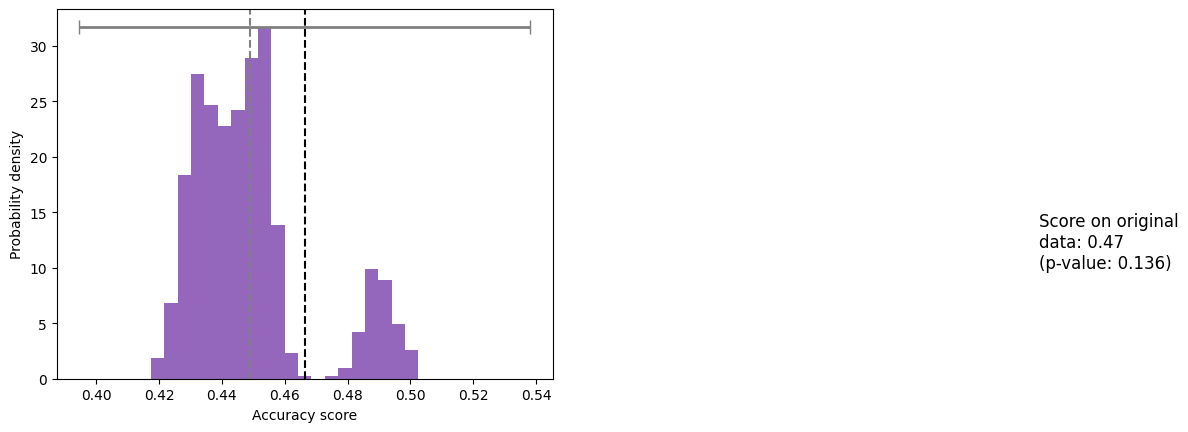

AIBR
Mean Accuracy: 0.473 (0.074)
[0.41666667 0.45454545 0.38461538 0.51162791 0.5952    ]


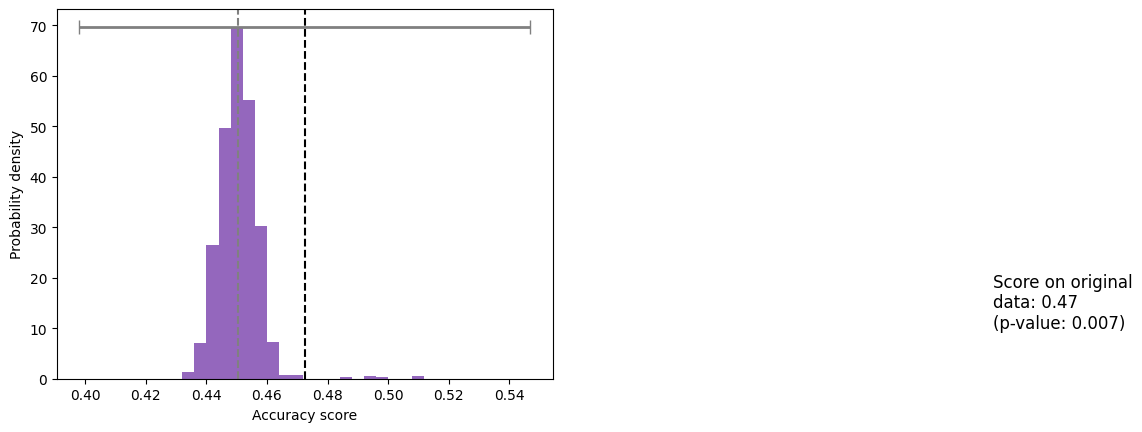

AIZL
Mean Accuracy: 0.554 (0.127)
[0.63333333 0.72727273 0.38461538 0.4344186  0.592     ]


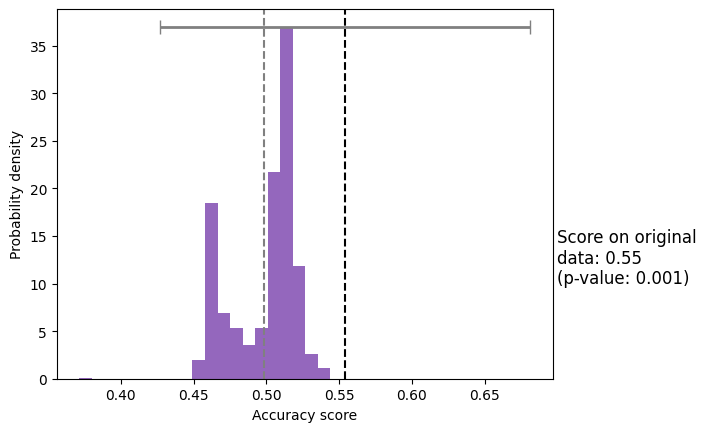

ALA
Mean Accuracy: 0.445 (0.057)
[0.41666667 0.55272727 0.38461538 0.42697674 0.4448    ]


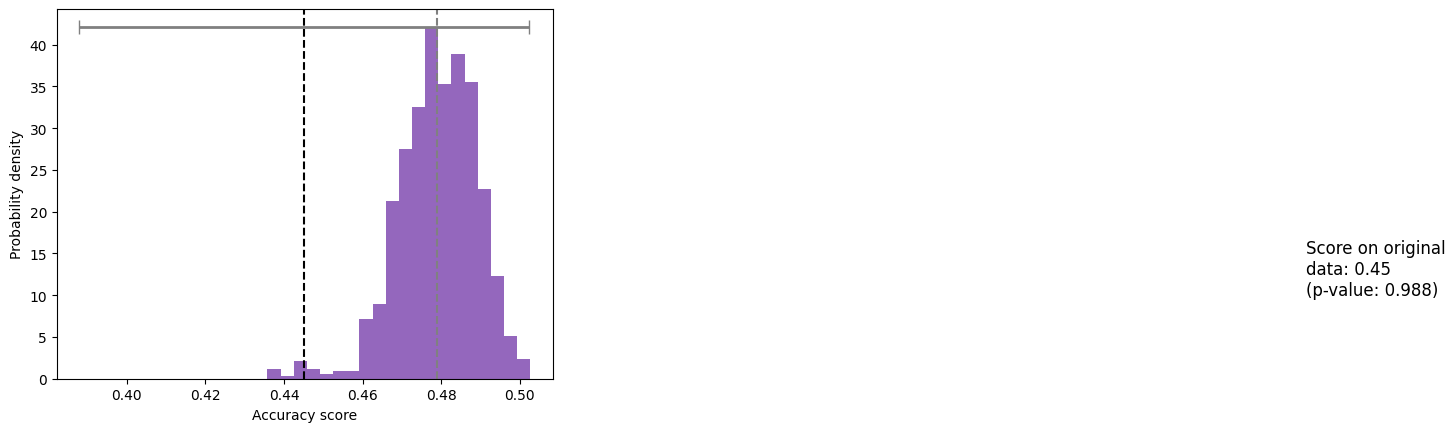

ALNL
Mean Accuracy: 0.467 (0.123)
[0.41666667 0.68       0.30153846 0.46418605 0.472     ]


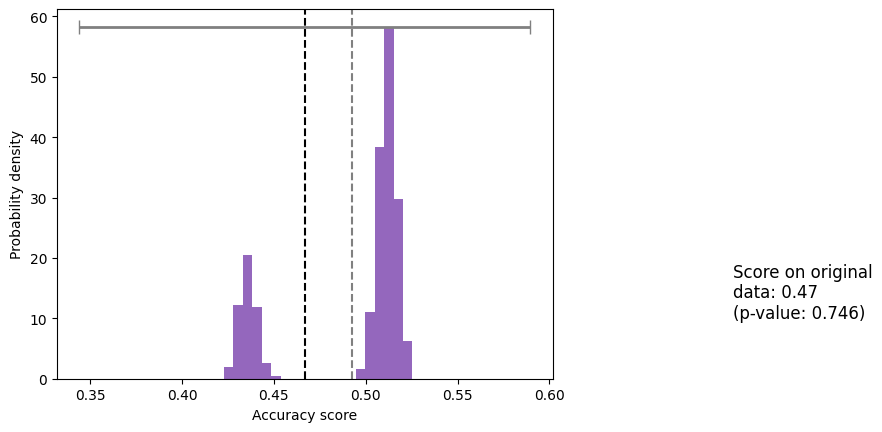

ALNR
Mean Accuracy: 0.367 (0.053)
[0.41666667 0.27272727 0.36       0.42046512 0.3648    ]


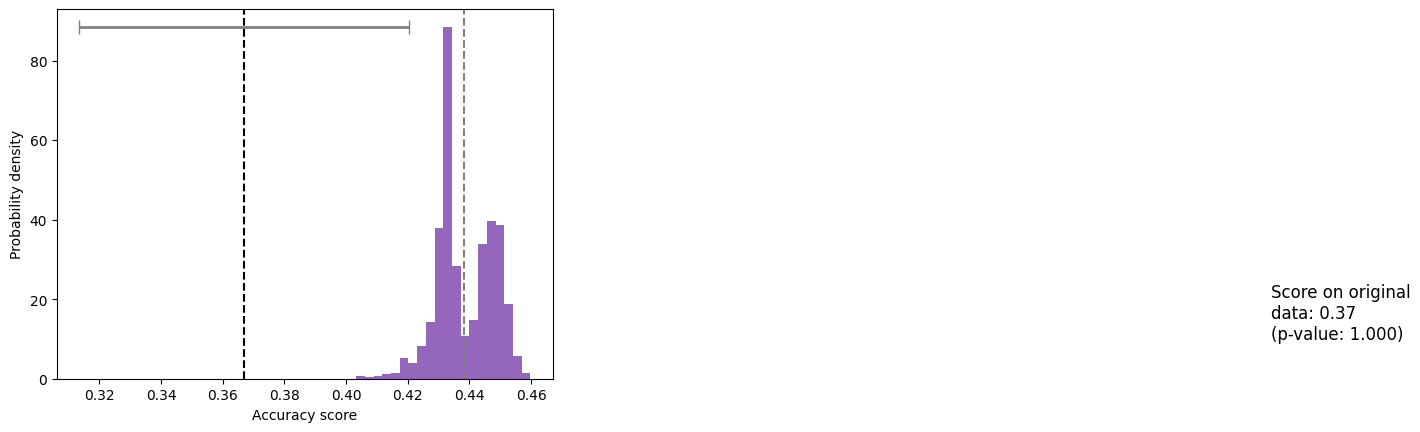

AQR
Mean Accuracy: 0.536 (0.128)
[0.72666667 0.41090909 0.38461538 0.53767442 0.6224    ]


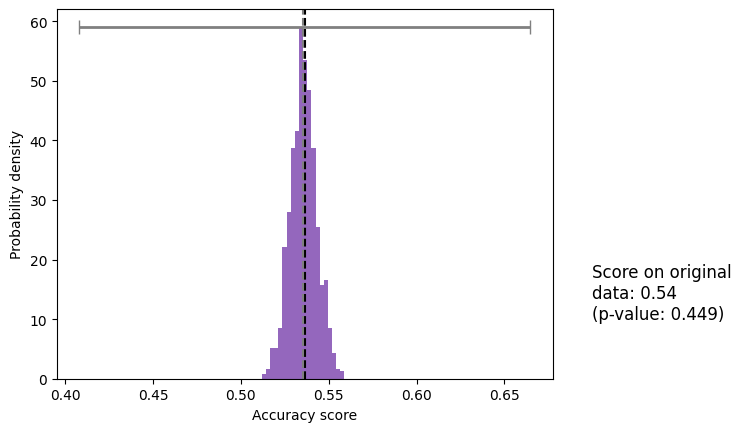

AS10
Mean Accuracy: 0.489 (0.082)
[0.42333333 0.51272727 0.38461538 0.62046512 0.5024    ]


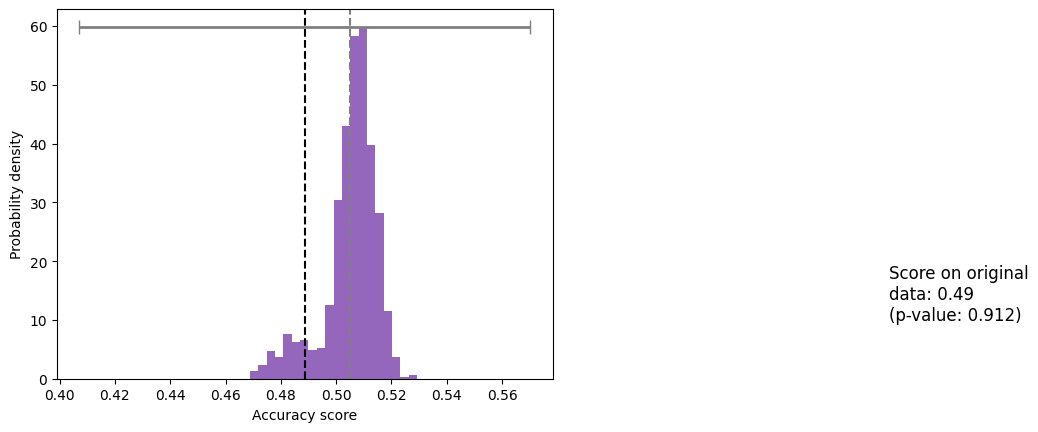

ASKL
Mean Accuracy: 0.559 (0.116)
[0.76666667 0.48363636 0.42461538 0.56186047 0.5584    ]


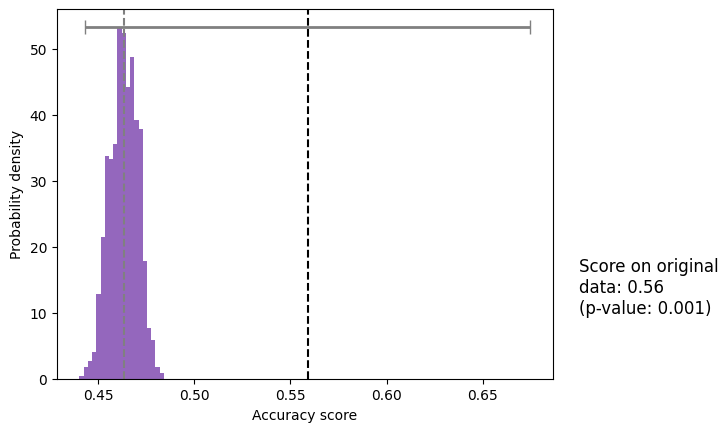

ASKR
Mean Accuracy: 0.372 (0.058)
[0.41666667 0.27272727 0.38307692 0.43906977 0.3472    ]


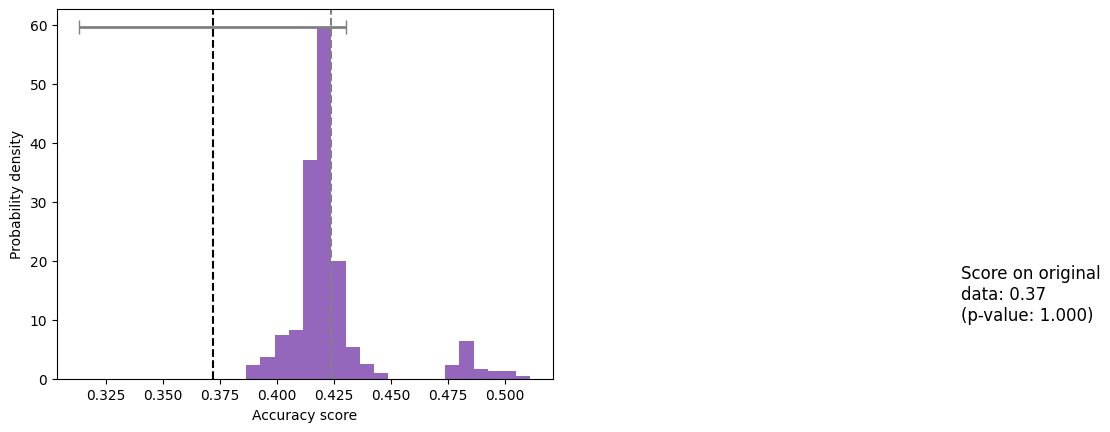

AUAL
Mean Accuracy: 0.345 (0.063)
[0.41666667 0.27272727 0.33076923 0.42139535 0.2848    ]


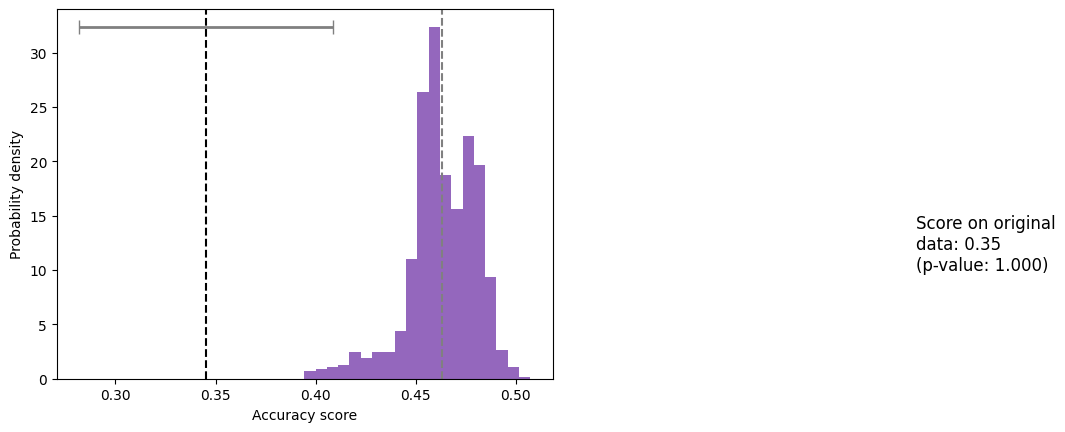

AUAR
Mean Accuracy: 0.587 (0.200)
[0.53666667 0.27272727 0.62615385 0.6        0.8976    ]


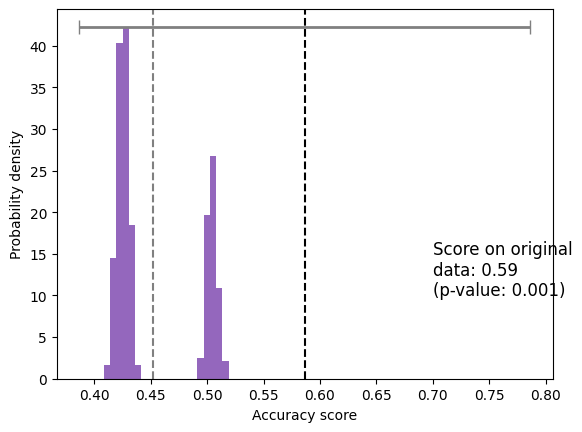

AVAL
Mean Accuracy: 0.464 (0.133)
[0.41666667 0.29090909 0.38461538 0.66604651 0.56      ]


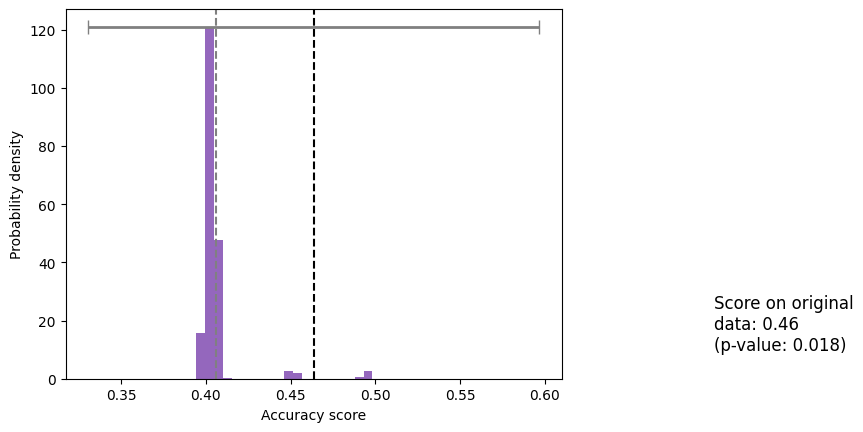

AVAR
Mean Accuracy: 0.354 (0.048)
[0.41666667 0.29090909 0.38461538 0.37302326 0.3072    ]


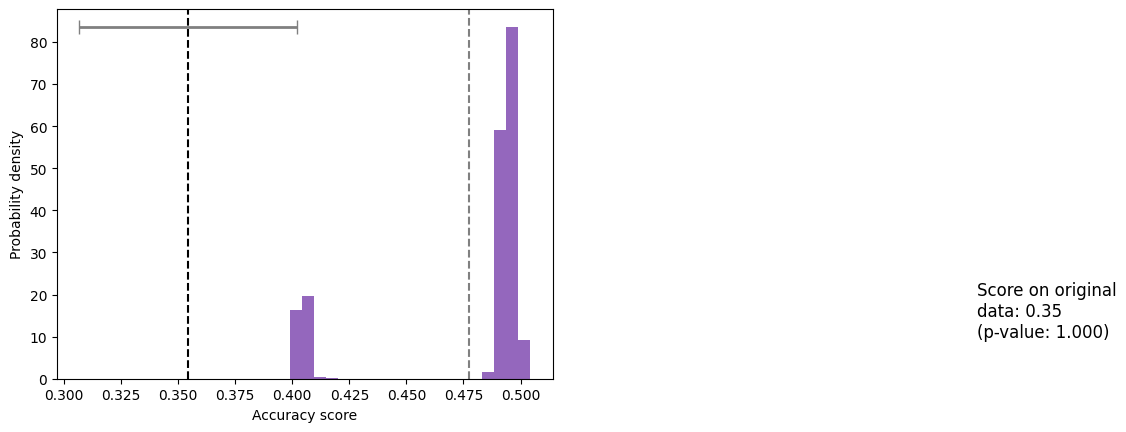

AVEL
Mean Accuracy: 0.509 (0.120)
[0.55333333 0.37454545 0.38615385 0.70139535 0.5296    ]


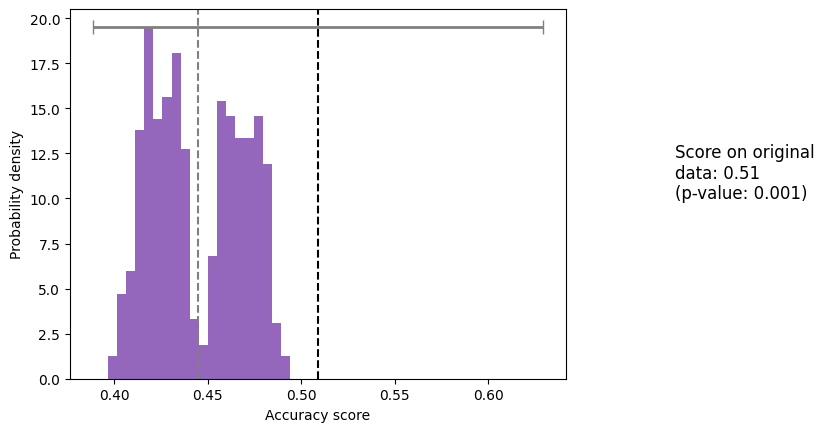

AVER
Mean Accuracy: 0.539 (0.159)
[0.41666667 0.33454545 0.52153846 0.64372093 0.7808    ]


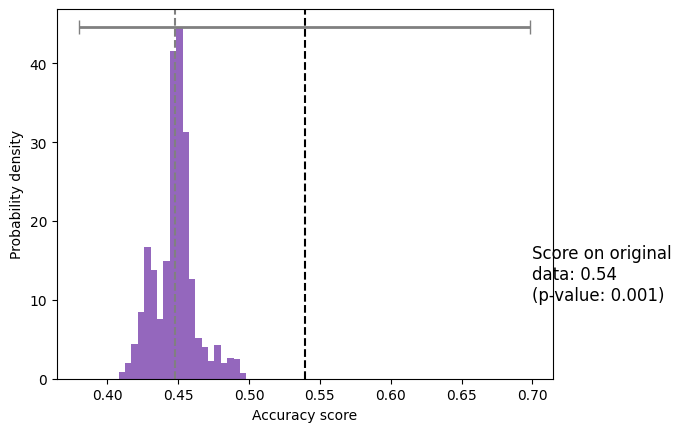

BAGL
Mean Accuracy: 0.464 (0.061)
[0.50333333 0.42545455 0.38461538 0.44837209 0.56      ]


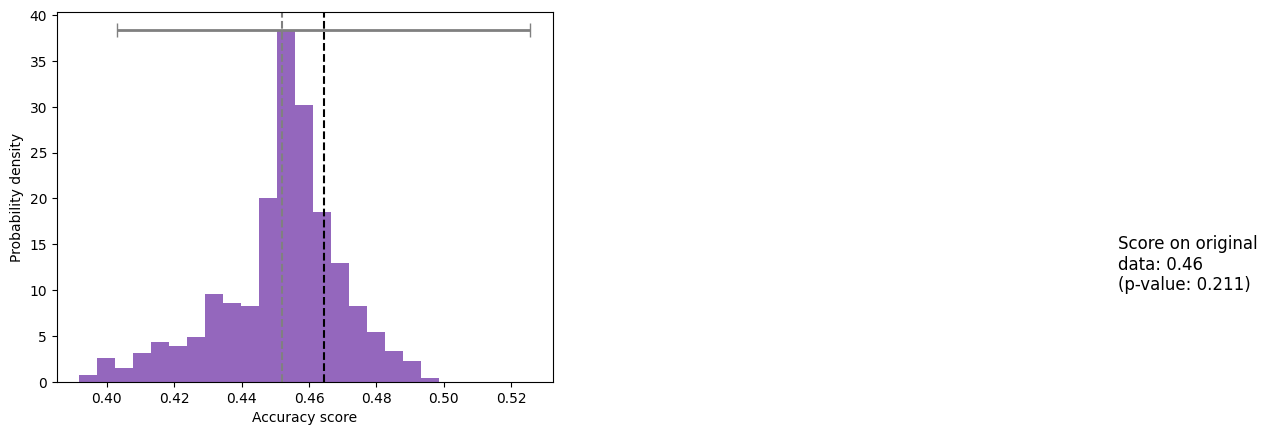

BAGR
Mean Accuracy: 0.383 (0.076)
[0.42       0.27272727 0.38461538 0.50046512 0.3392    ]


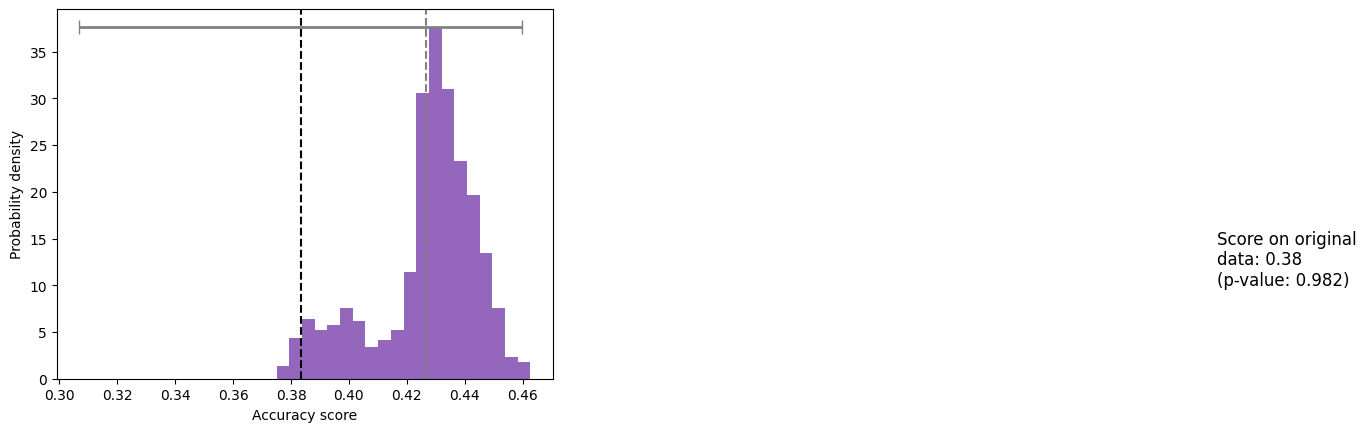

DA01
Mean Accuracy: 0.476 (0.094)
[0.42666667 0.38909091 0.38461538 0.59255814 0.5856    ]


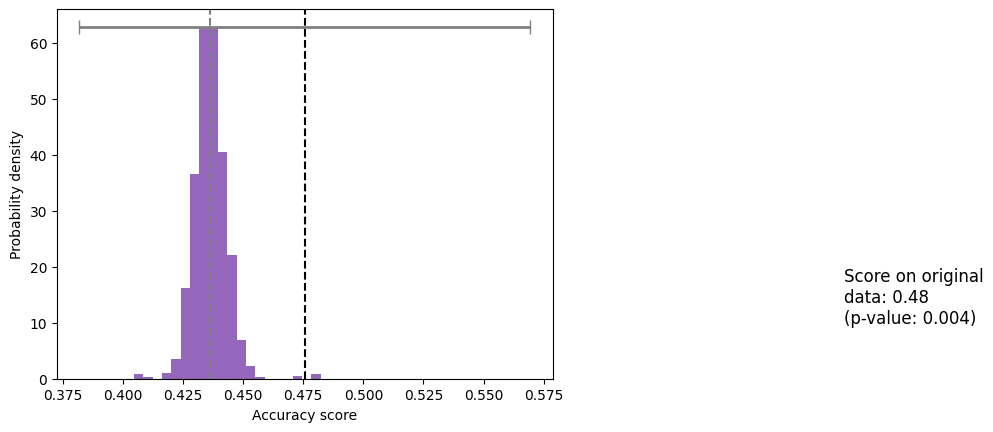

DA07
Mean Accuracy: 0.516 (0.074)
[0.48333333 0.56727273 0.38461538 0.58232558 0.56      ]


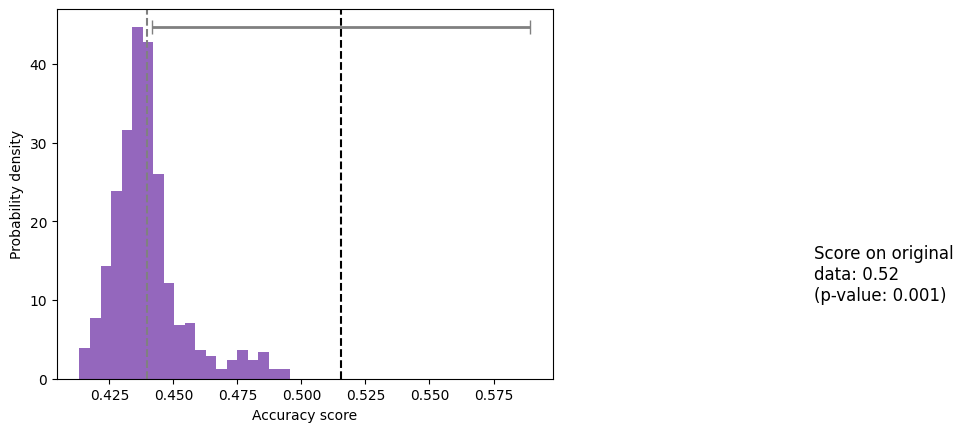

DA09
Mean Accuracy: 0.455 (0.053)
[0.41666667 0.54181818 0.38461538 0.46511628 0.4672    ]


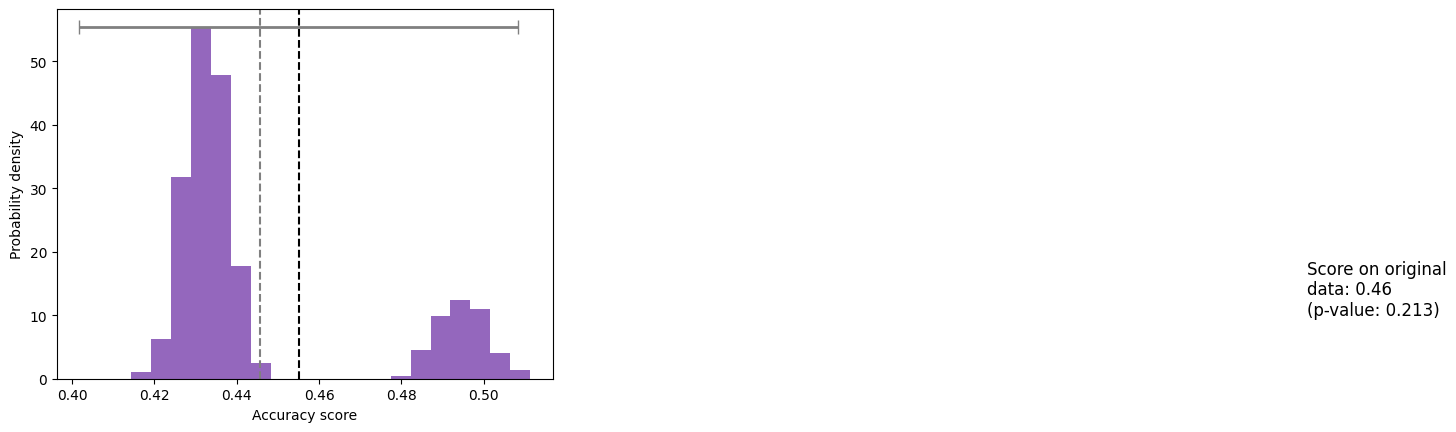

DB01
Mean Accuracy: 0.410 (0.079)
[0.41666667 0.29818182 0.37384615 0.42046512 0.5408    ]


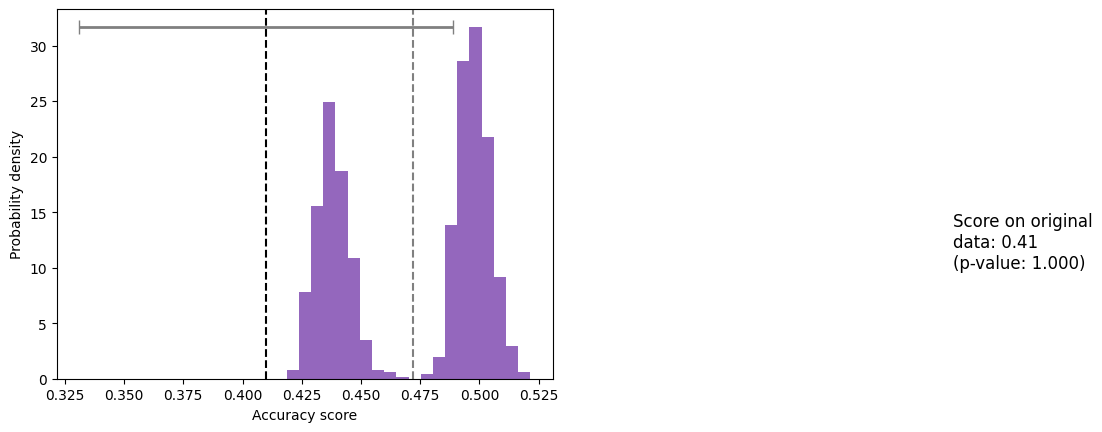

DB02
Mean Accuracy: 0.595 (0.162)
[0.83       0.44727273 0.38769231 0.61116279 0.7008    ]


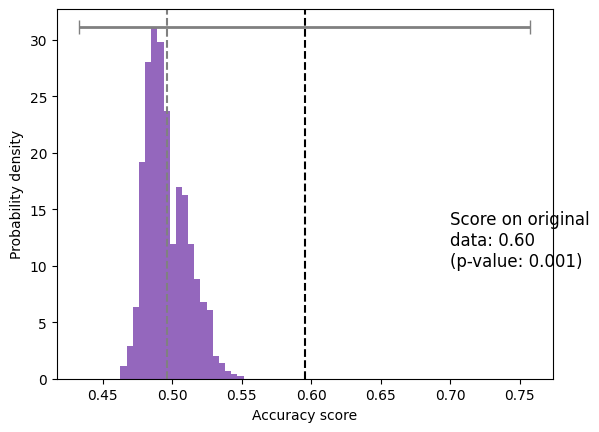

DB07
Mean Accuracy: 0.505 (0.064)
[0.5        0.54181818 0.38461538 0.56465116 0.536     ]


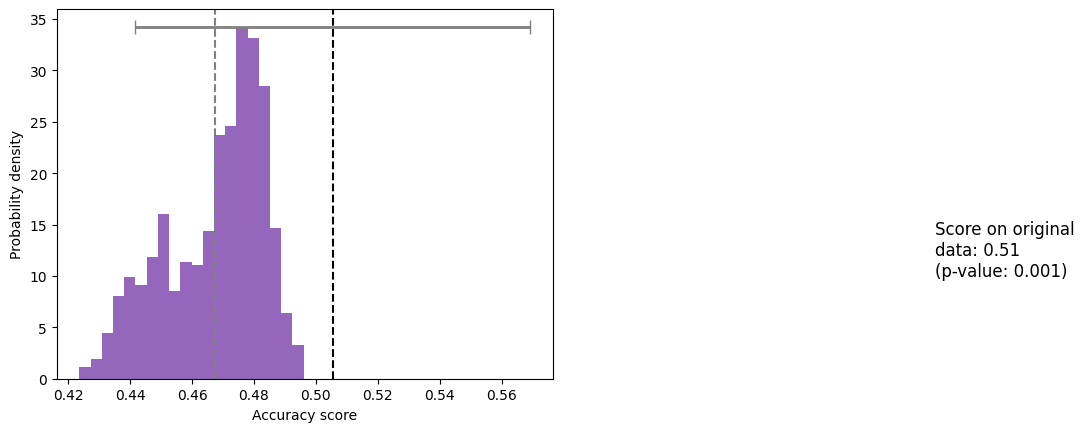

DVA
Mean Accuracy: 0.535 (0.080)
[0.58       0.61818182 0.54615385 0.54511628 0.384     ]


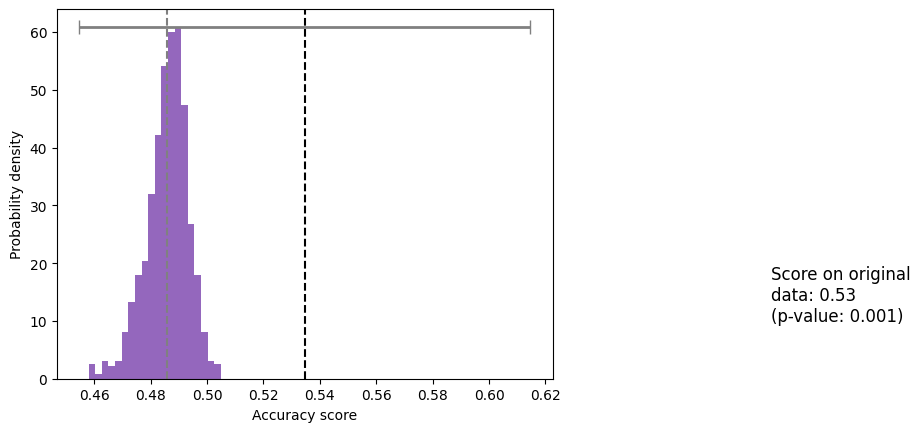

IL2L
Mean Accuracy: 0.434 (0.149)
[0.41666667 0.24363636 0.38461538 0.42232558 0.7008    ]


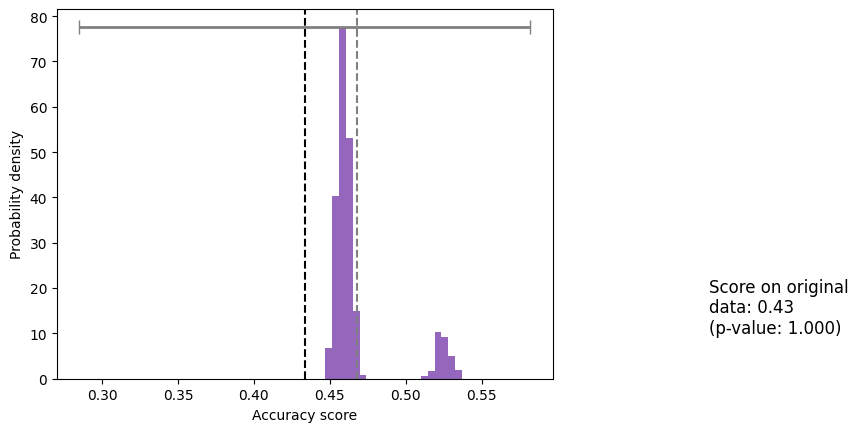

IL2R
Mean Accuracy: 0.482 (0.157)
[0.47666667 0.72727273 0.38461538 0.26325581 0.56      ]


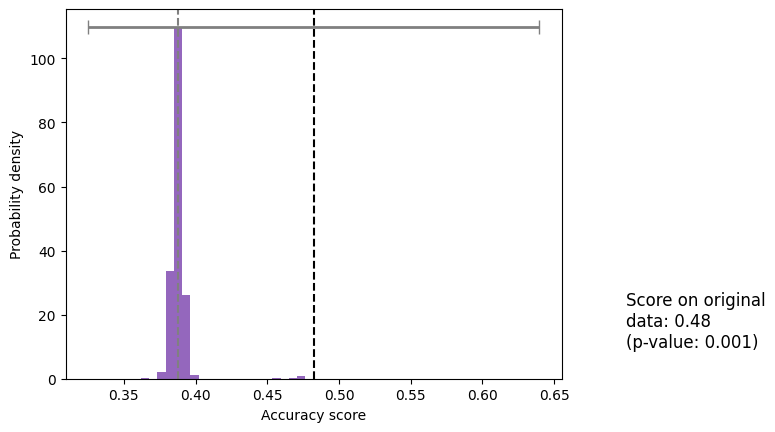

PQR
Mean Accuracy: 0.516 (0.156)
[0.36666667 0.72727273 0.38461538 0.41953488 0.6832    ]


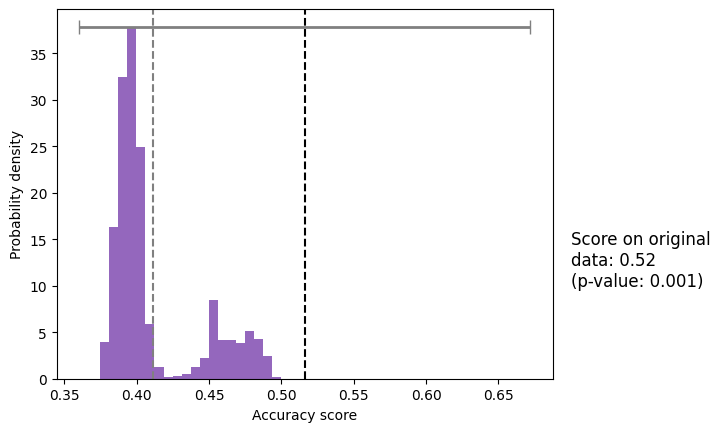

PVNL
Mean Accuracy: 0.431 (0.108)
[0.41666667 0.27272727 0.38461538 0.47813953 0.6016    ]


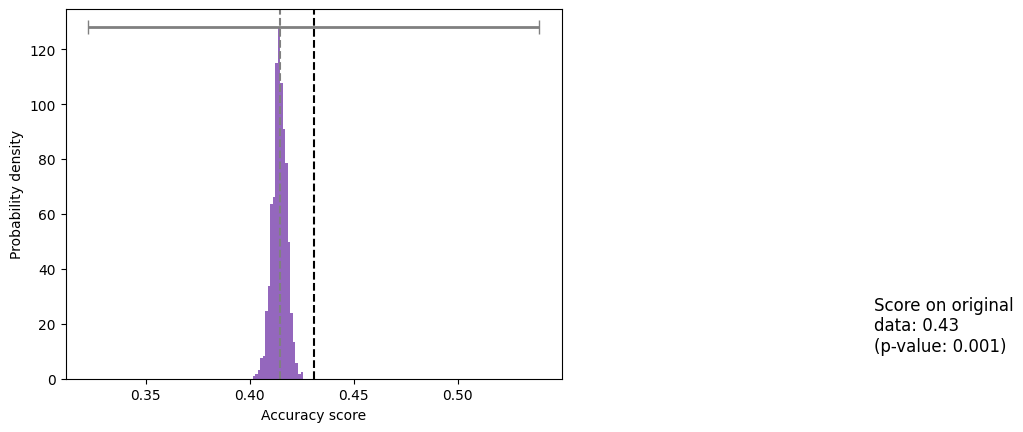

PVNR
Mean Accuracy: 0.583 (0.083)
[0.59       0.71636364 0.46461538 0.53674419 0.608     ]


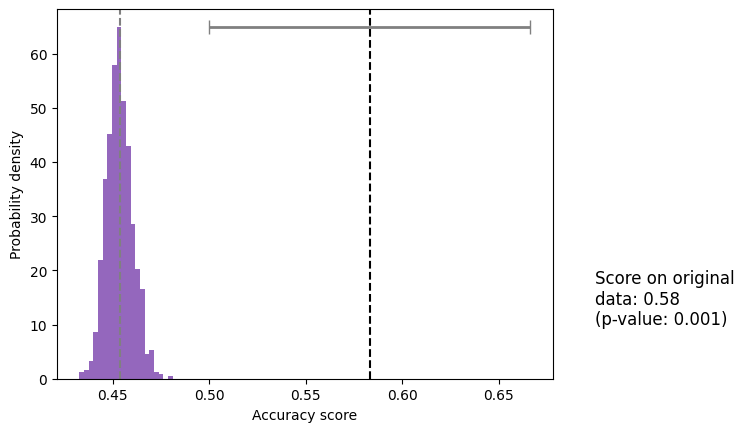

PVPL
Mean Accuracy: 0.618 (0.074)
[0.58333333 0.49454545 0.67076923 0.70883721 0.632     ]


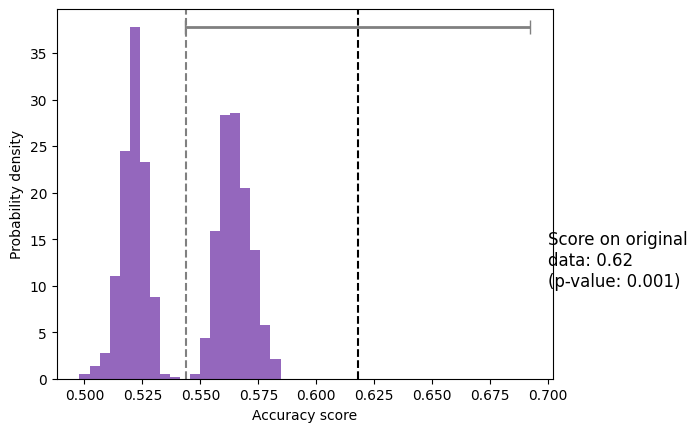

RIBL
Mean Accuracy: 0.620 (0.105)
[0.76333333 0.48727273 0.52307692 0.61860465 0.7088    ]


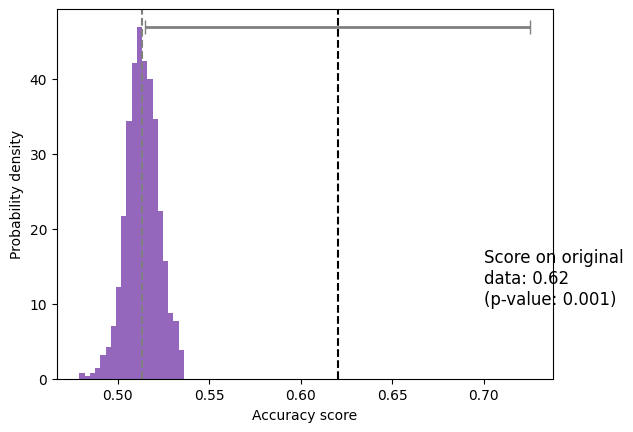

RIBR
Mean Accuracy: 0.612 (0.134)
[0.83333333 0.44363636 0.51692308 0.59162791 0.672     ]


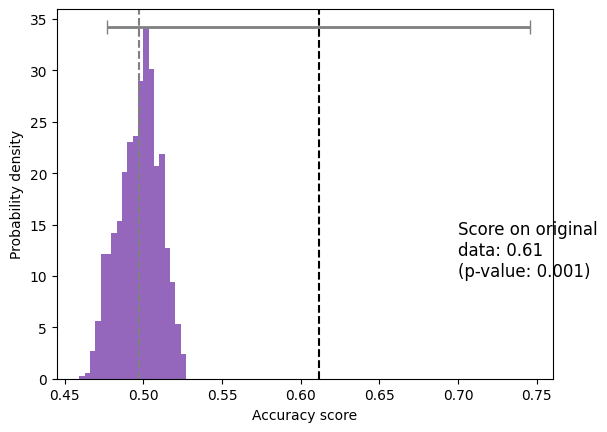

RID
Mean Accuracy: 0.445 (0.060)
[0.41666667 0.38909091 0.38461538 0.50604651 0.528     ]


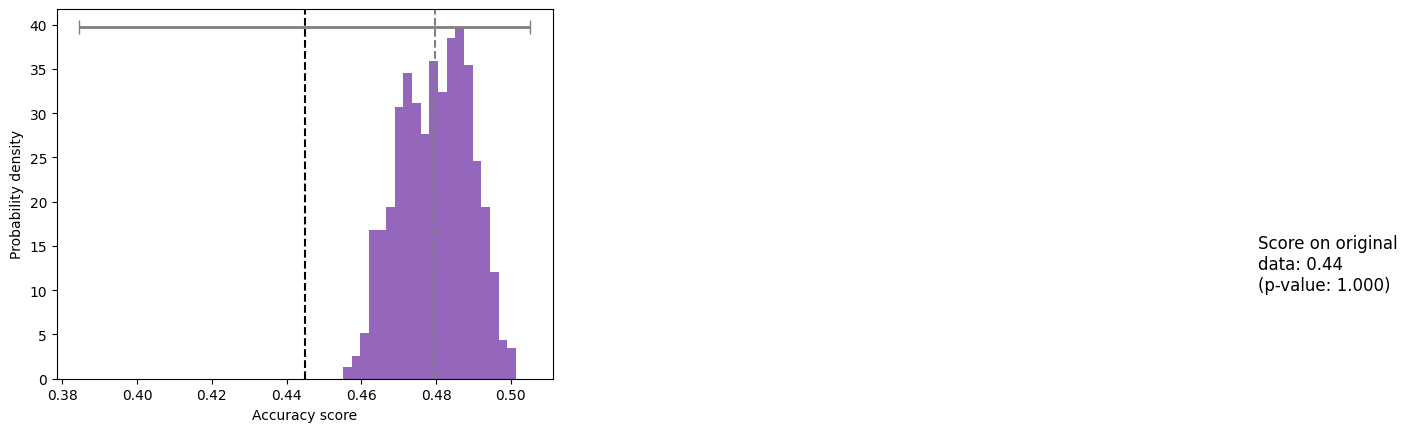

RIML
Mean Accuracy: 0.506 (0.238)
[0.41666667 0.19636364 0.38461538 0.64372093 0.8864    ]


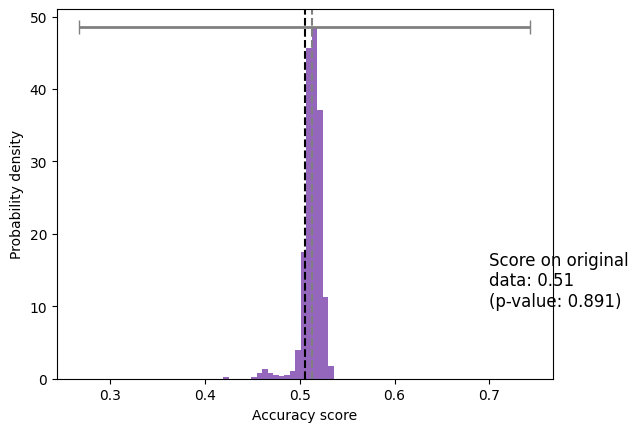

RIMR
Mean Accuracy: 0.405 (0.080)
[0.41666667 0.33454545 0.38461538 0.33581395 0.552     ]


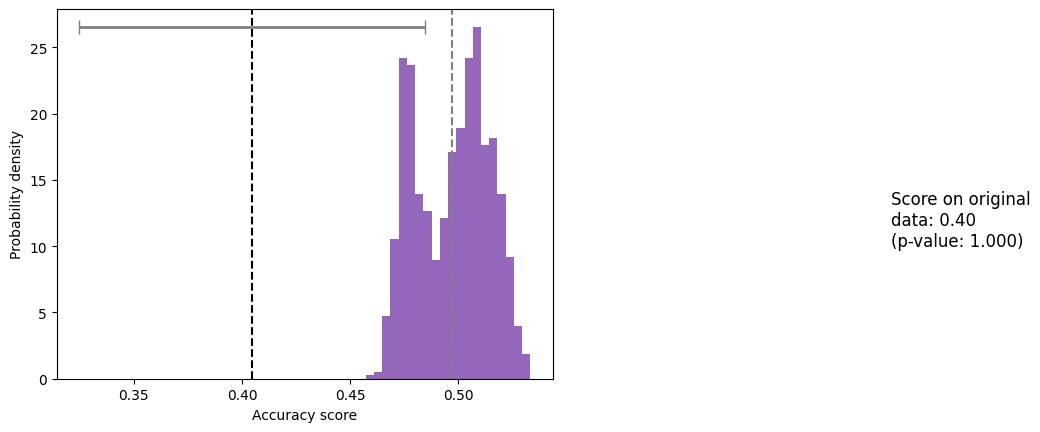

RIS
Mean Accuracy: 0.631 (0.205)
[0.85333333 0.27272727 0.62461538 0.59348837 0.8096    ]


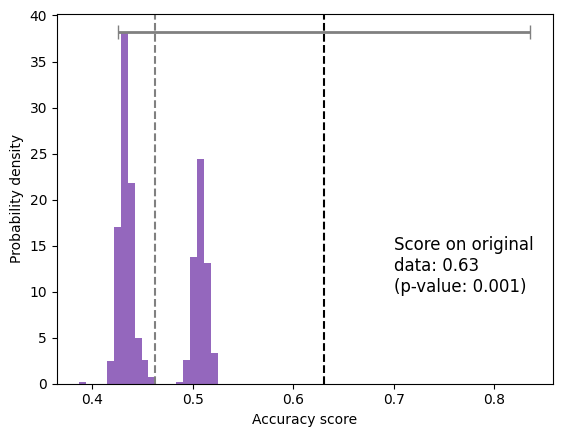

RIVL
Mean Accuracy: 0.466 (0.094)
[0.41666667 0.37090909 0.38461538 0.59627907 0.5632    ]


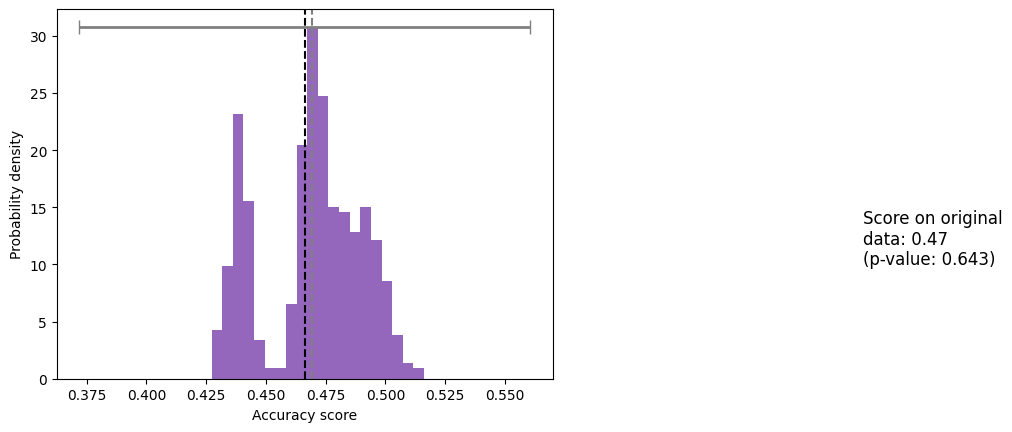

RIVR
Mean Accuracy: 0.532 (0.113)
[0.41666667 0.60363636 0.38461538 0.57395349 0.68      ]


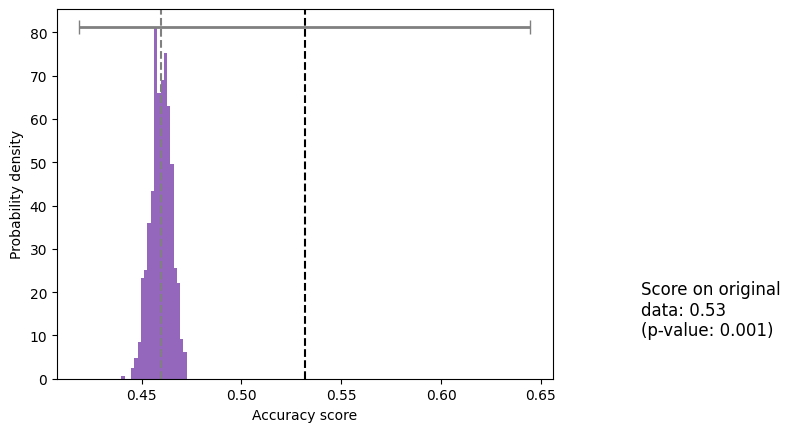

RMGL
Mean Accuracy: 0.568 (0.151)
[0.45333333 0.45090909 0.46615385 0.62976744 0.8384    ]


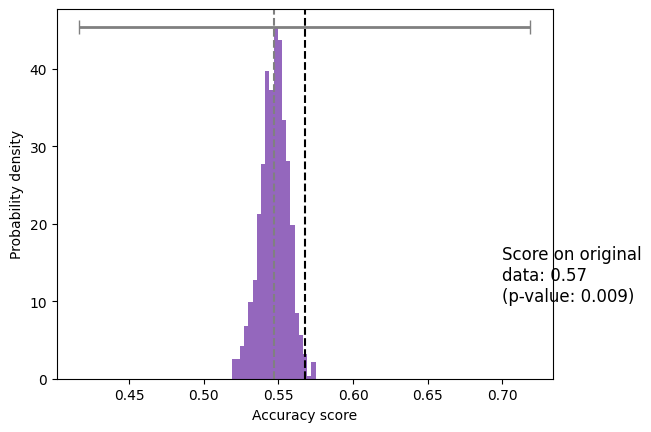

RMGR
Mean Accuracy: 0.443 (0.072)
[0.41666667 0.54545455 0.38461538 0.50976744 0.3584    ]


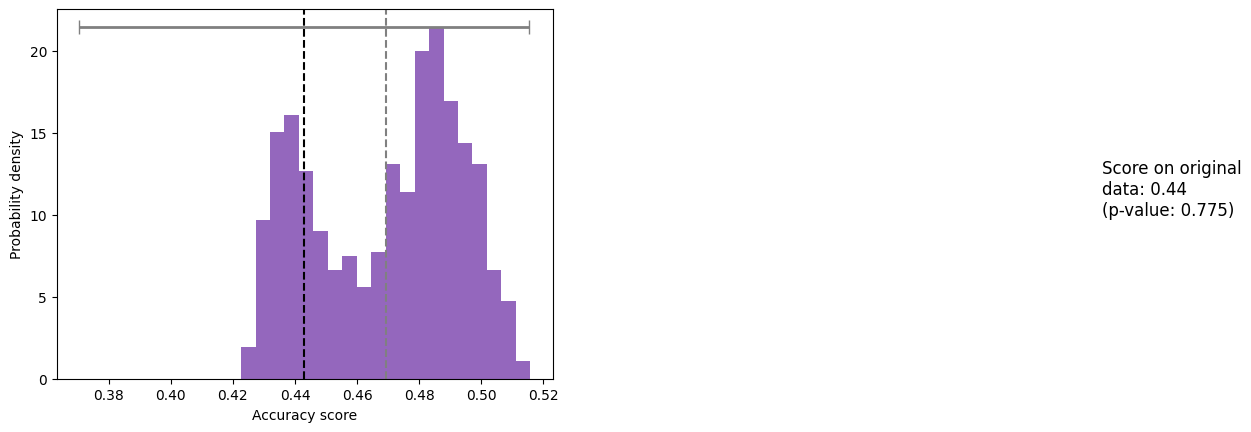

SIADL
Mean Accuracy: 0.364 (0.074)
[0.41666667 0.44727273 0.38461538 0.33488372 0.2368    ]


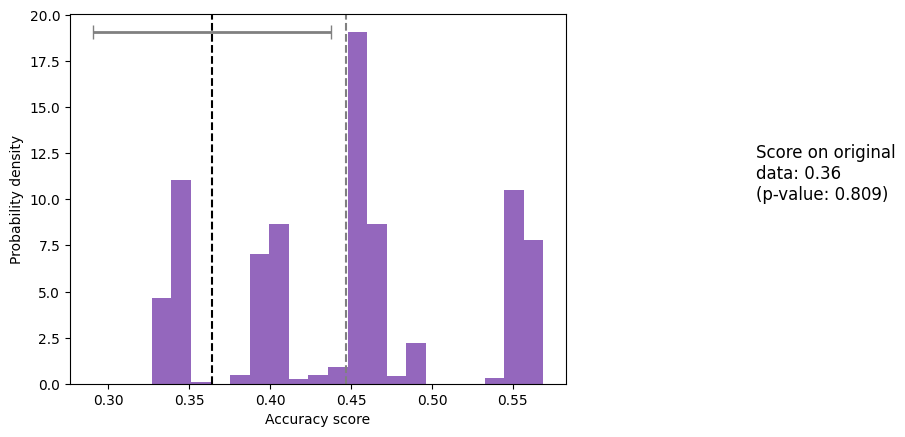

SIADR
Mean Accuracy: 0.470 (0.118)
[0.41666667 0.53818182 0.38461538 0.34325581 0.6656    ]


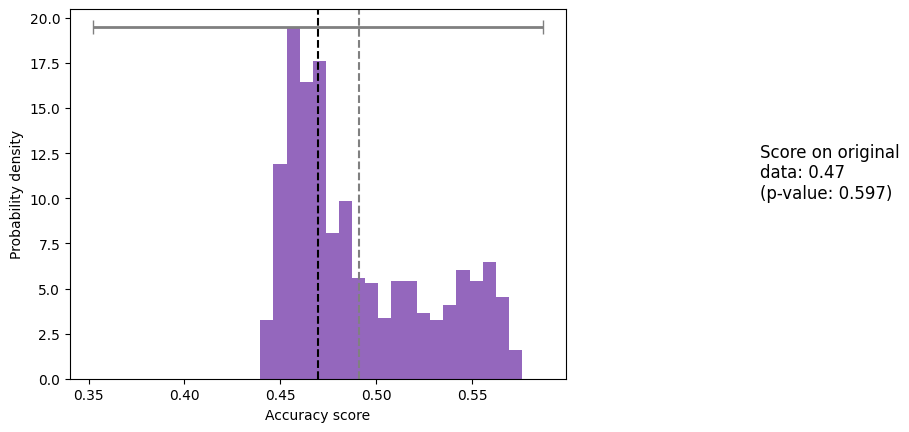

SMBDL
Mean Accuracy: 0.560 (0.093)
[0.58333333 0.63272727 0.39538462 0.53116279 0.6576    ]


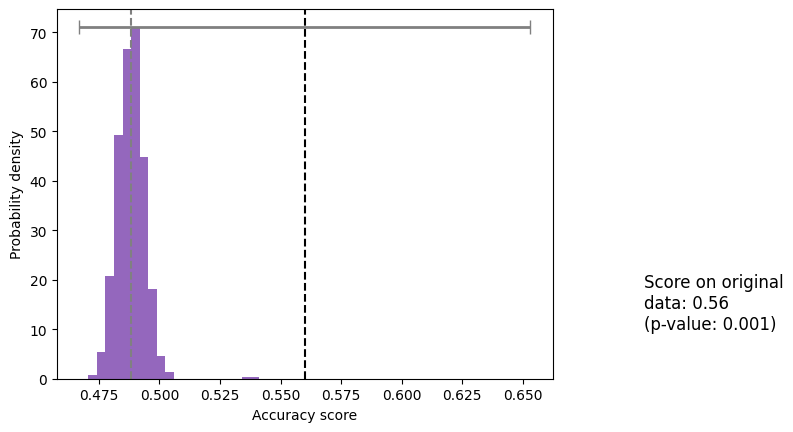

SMBDR
Mean Accuracy: 0.544 (0.094)
[0.58333333 0.53090909 0.37076923 0.58790698 0.6464    ]


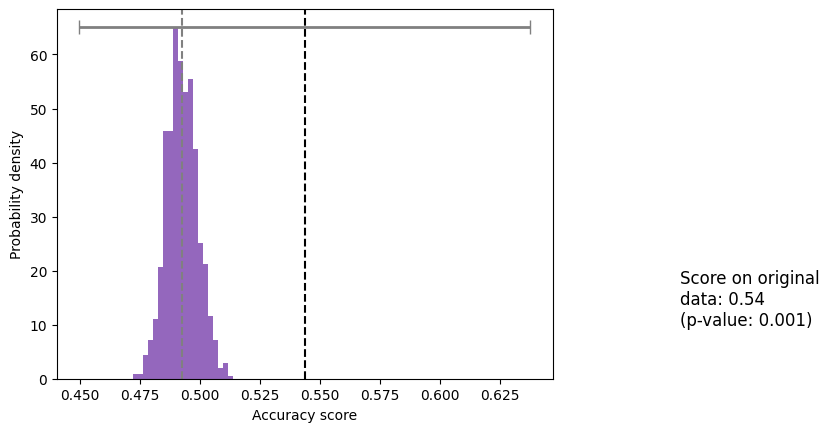

SMBVL
Mean Accuracy: 0.484 (0.094)
[0.41666667 0.42181818 0.38461538 0.60372093 0.5936    ]


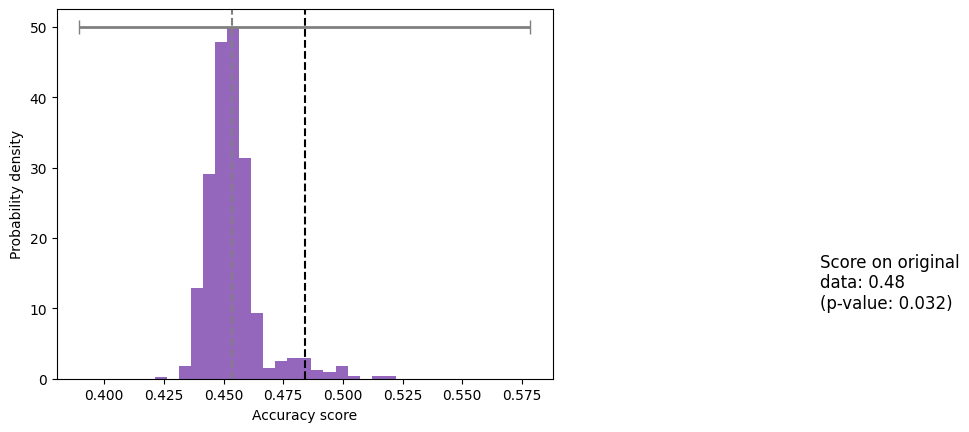

SMDDL
Mean Accuracy: 0.390 (0.045)
[0.43333333 0.39636364 0.38461538 0.42697674 0.3088    ]


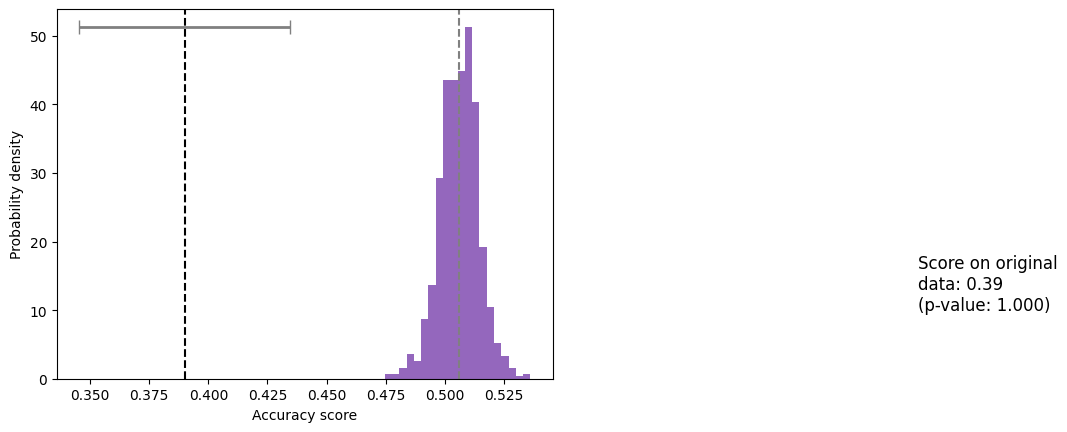

SMDDR
Mean Accuracy: 0.455 (0.077)
[0.44666667 0.54545455 0.38461538 0.3572093  0.5392    ]


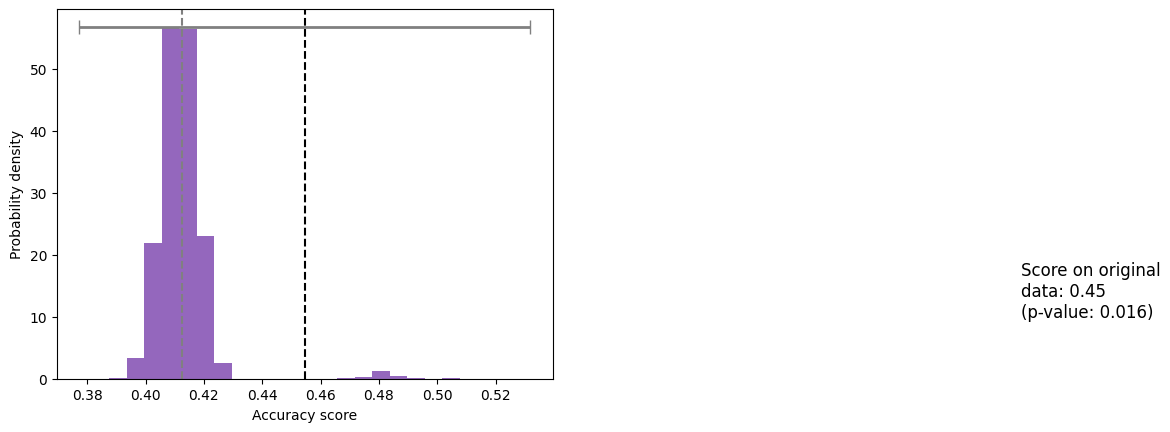

SMDVL
Mean Accuracy: 0.507 (0.116)
[0.41666667 0.58181818 0.38461538 0.45674419 0.696     ]


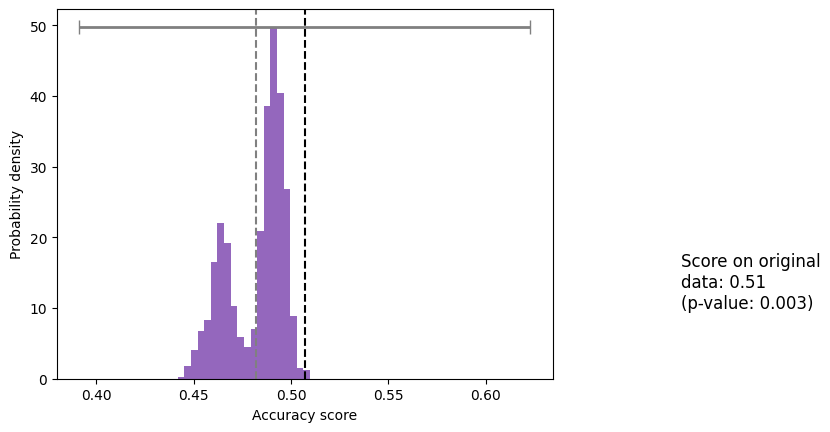

SMDVR
Mean Accuracy: 0.454 (0.074)
[0.36333333 0.49454545 0.38461538 0.45953488 0.5664    ]


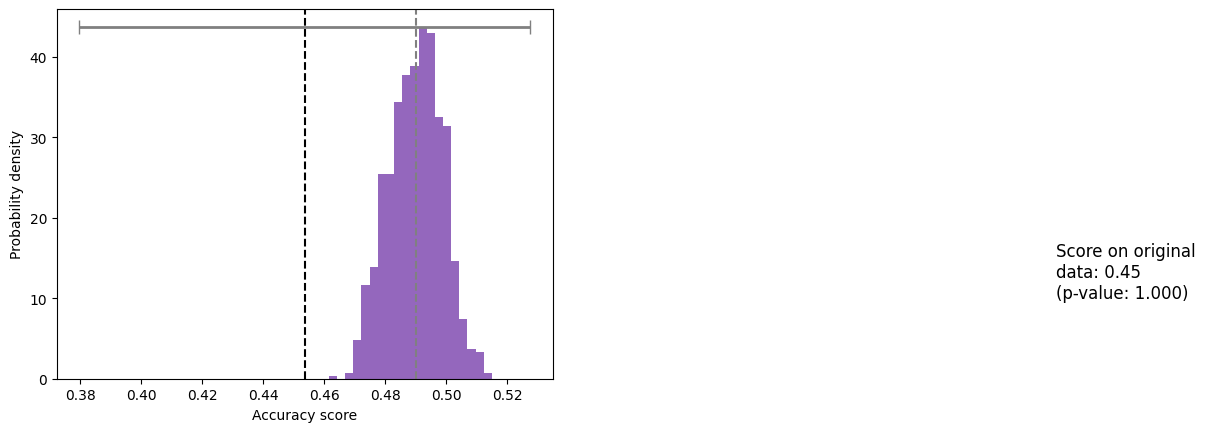

URXL
Mean Accuracy: 0.596 (0.099)
[0.54666667 0.49818182 0.57692308 0.57116279 0.7856    ]


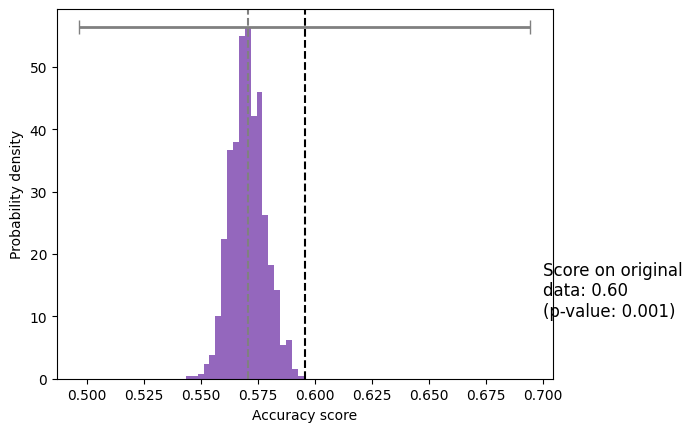

URXR
Mean Accuracy: 0.491 (0.155)
[0.63666667 0.24727273 0.38461538 0.65116279 0.5344    ]


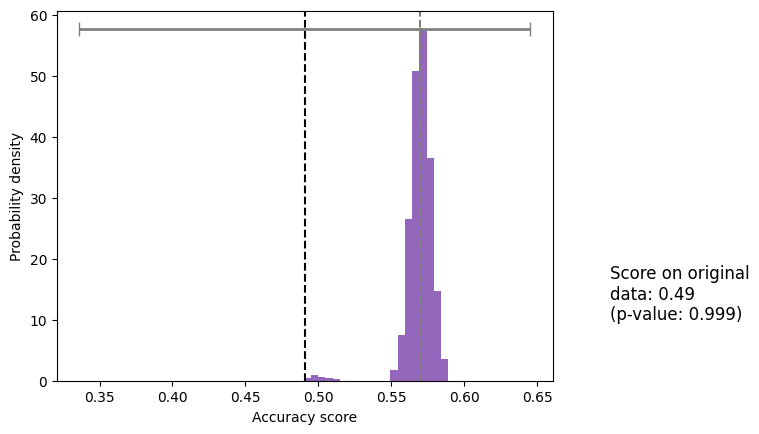

URYDL
Mean Accuracy: 0.392 (0.053)
[0.41666667 0.29454545 0.38307692 0.41395349 0.4512    ]


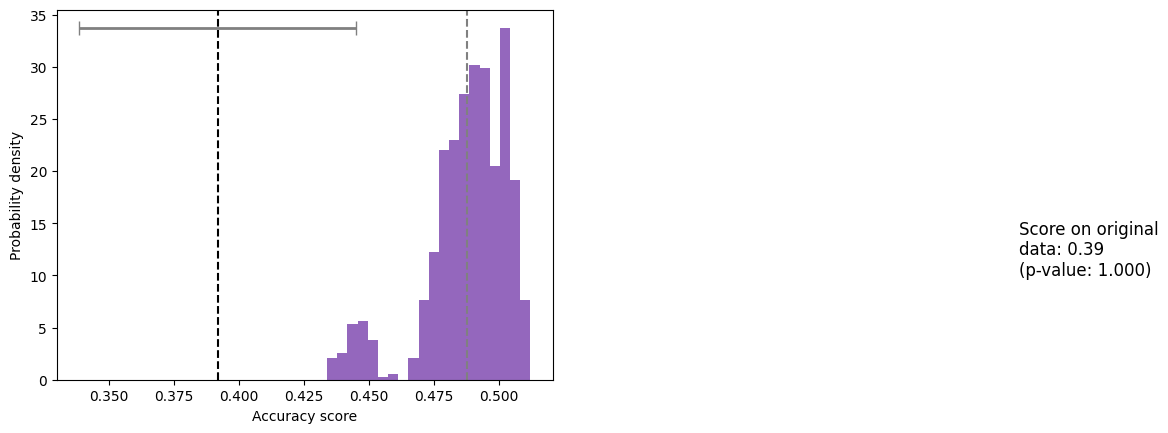

URYDR
Mean Accuracy: 0.502 (0.091)
[0.41666667 0.60363636 0.38461538 0.60186047 0.5008    ]


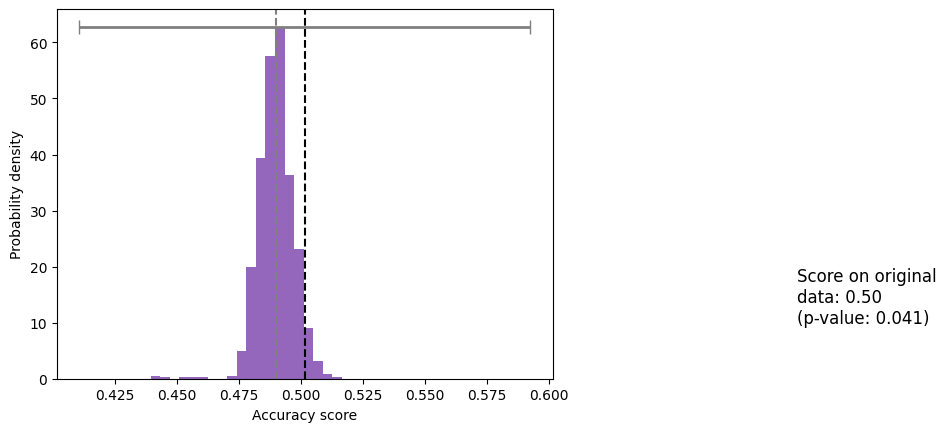

URYVL
Mean Accuracy: 0.380 (0.083)
[0.47666667 0.27272727 0.30769231 0.37209302 0.472     ]


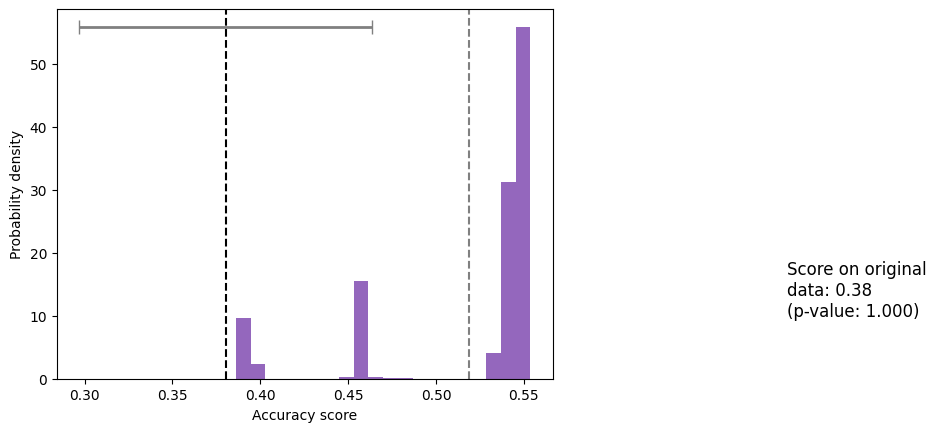

URYVR
Mean Accuracy: 0.445 (0.150)
[0.47333333 0.72727273 0.33692308 0.34139535 0.344     ]


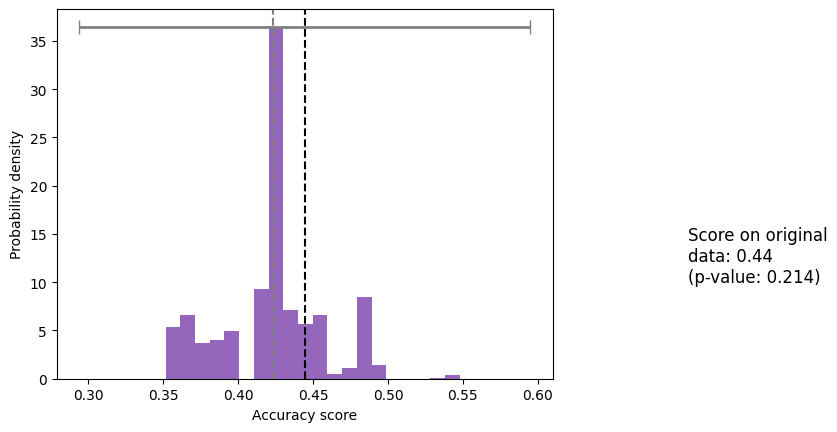

VA01
Mean Accuracy: 0.450 (0.084)
[0.51       0.31636364 0.38615385 0.53860465 0.4976    ]


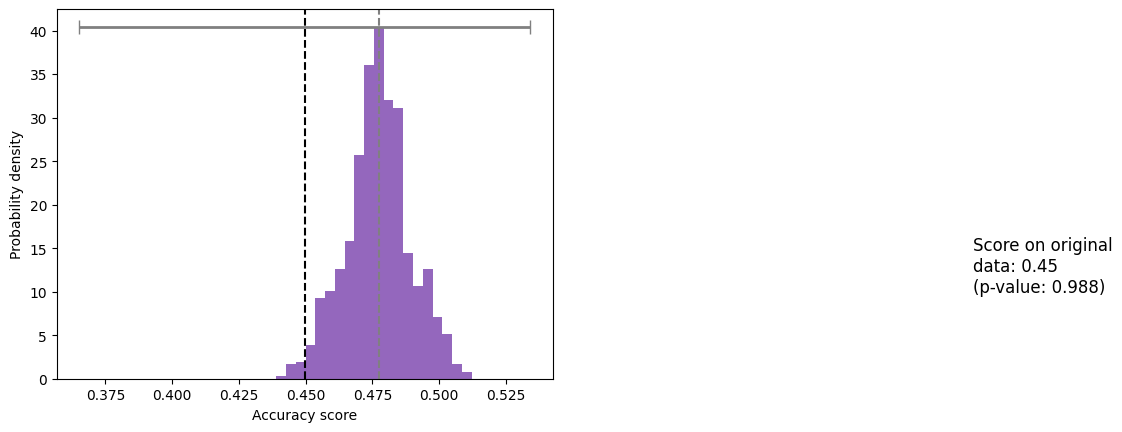

VA11
Mean Accuracy: 0.392 (0.027)
[0.41666667 0.36363636 0.38461538 0.36465116 0.4288    ]


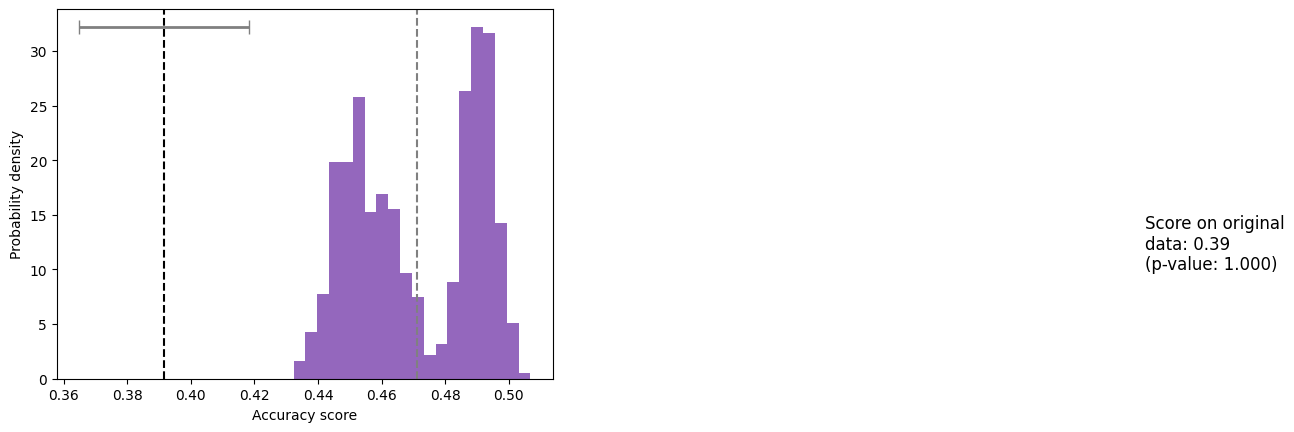

VA12
Mean Accuracy: 0.426 (0.082)
[0.42       0.45454545 0.38461538 0.31069767 0.56      ]


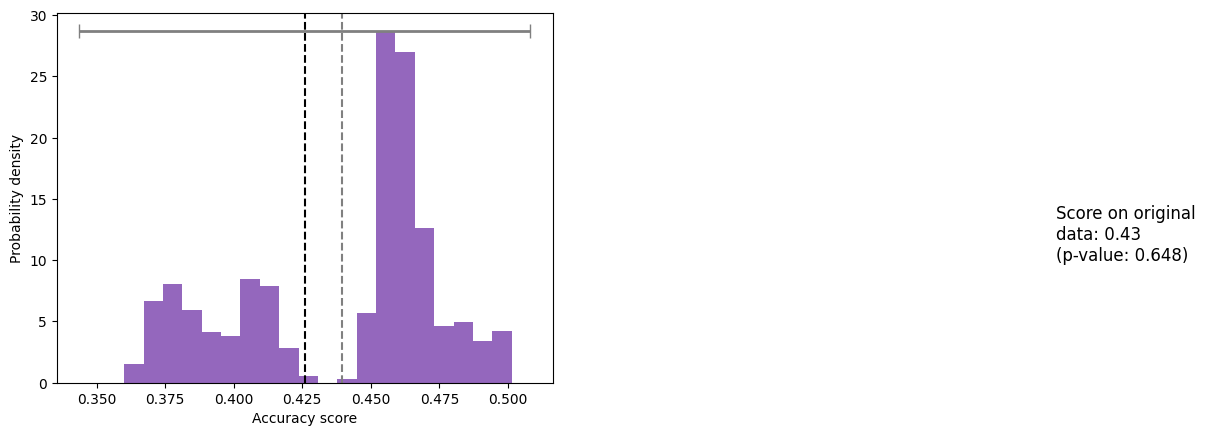

VB01
Mean Accuracy: 0.475 (0.130)
[0.41666667 0.35636364 0.35846154 0.55348837 0.6912    ]


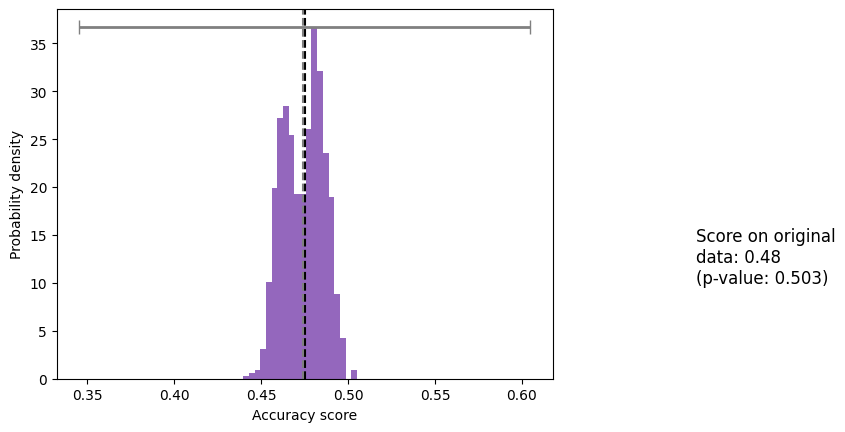

VB02
Mean Accuracy: 0.428 (0.094)
[0.41666667 0.27272727 0.40923077 0.48465116 0.5568    ]


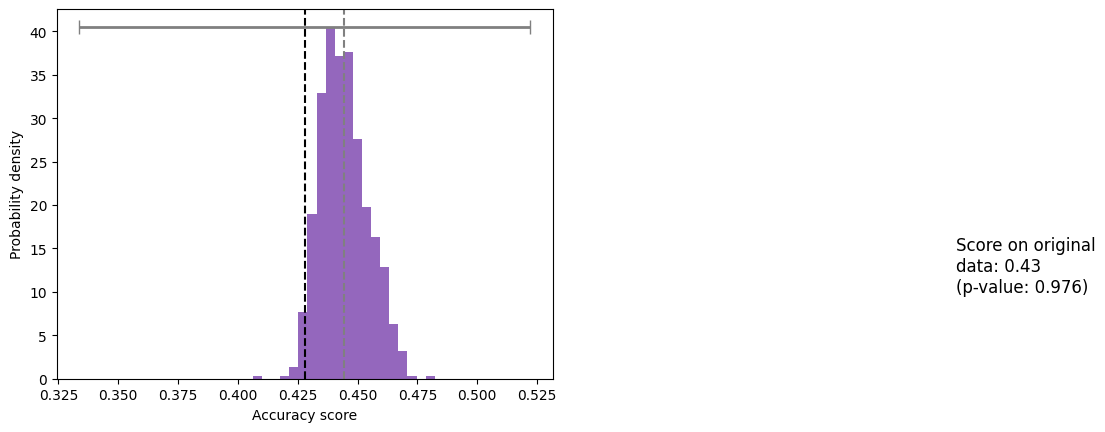

VD13
Mean Accuracy: 0.508 (0.091)
[0.41666667 0.60727273 0.38461538 0.54418605 0.5872    ]


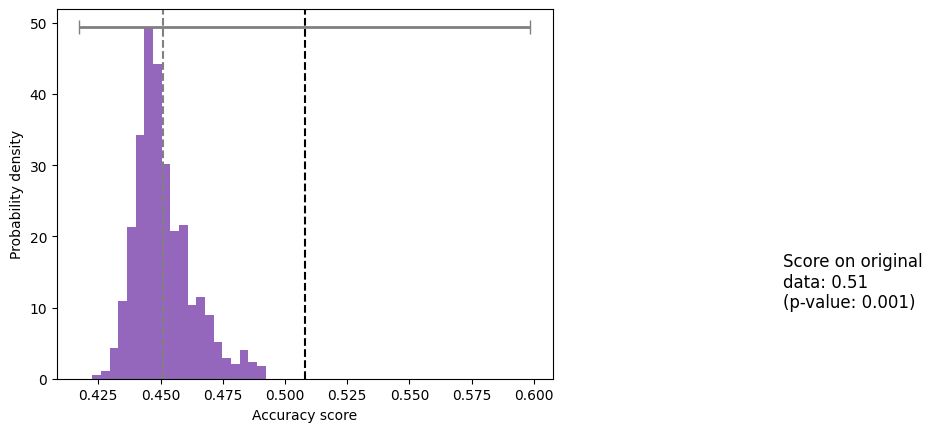

state
Mean Accuracy: 0.495 (0.088)
[0.41666667 0.58545455 0.36307692 0.54976744 0.56      ]


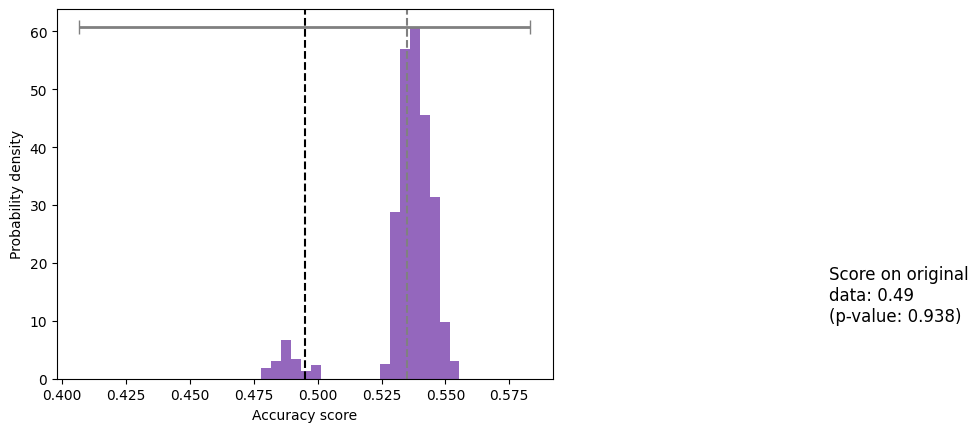

In [35]:
o=single_neuron_lda(sliced_df_forPLS)

In [36]:
w=o.sort_values(["p-value"],ascending=True)
pd.set_option('display.max_rows', 83) 
w

,mean_accuracy,std,perm_accuaracy,p-value
RIBL,0.620218,0.105302,0.513404,0.000999
PQR,0.516258,0.155859,0.411181,0.000999
IL2R,0.482362,0.157228,0.388102,0.000999
PVPL,0.617897,0.074397,0.543863,0.000999
DVA,0.53469,0.079964,0.485849,0.000999
DB07,0.505417,0.063861,0.467462,0.000999
DB02,0.595386,0.16216,0.495972,0.000999
VD13,0.507988,0.090557,0.451033,0.000999
RIBR,0.611504,0.134453,0.497354,0.000999
DA07,0.515509,0.073881,0.439797,0.000999


In [121]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import permutation_test_score
from math import ceil, sqrt

def permutation_grid_significant(df, o, n_permutations=100):

    # Select significant neurons
    sig_neurons = o[o['p-value'] < 0.05].index.tolist()

    if len(sig_neurons) == 0:
        print("No significant neurons")
        return

    n = len(sig_neurons)

    # Grid size
    ncols = int(ceil(sqrt(n)))
    nrows = int(ceil(n/ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4*ncols,3*nrows))

    axes = np.array(axes).reshape(-1)

    for ax, neuron in zip(axes, sig_neurons):

        print("Running:", neuron)

        ind_nan = df[neuron].isna()
        ind = ind_nan[ind_nan==False].index

        X = df[[neuron]].dropna()
        y = df.loc[ind,'target']
        groups = df.loc[ind,'group']

        model = LinearDiscriminantAnalysis()

        cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=0
        )

        score, perm_scores, pvalue = permutation_test_score(
            model,
            X,
            y,
            scoring="accuracy",
            cv=cv,
            groups=groups,
            n_permutations=n_permutations
        )

        m = score
        s = np.std(perm_scores)
        perm_mean = np.mean(perm_scores)

        hist_data, bins, _ = ax.hist(
            perm_scores,
            bins=20,
            density=True
        )

        ax.errorbar(m, hist_data.max(),
                    xerr=s,
                    lw=2,
                    capsize=5)

        ax.axvline(m, ls="--")
        ax.axvline(perm_mean, ls="--")

        ax.set_title(neuron)

        ax.text(
            0.6,
            0.85,
            f"acc={m:.2f}\np={pvalue:.3f}",
            transform=ax.transAxes
        )

        ax.set_xlabel("Accuracy")
        ax.set_ylabel("Density")


    # Remove empty axes
    for i in range(len(sig_neurons), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

Running: ASKL
Running: AVEL
Running: AVER
Running: DB02
Running: PVNR
Running: RIBL
Running: RIBR
Running: RIS


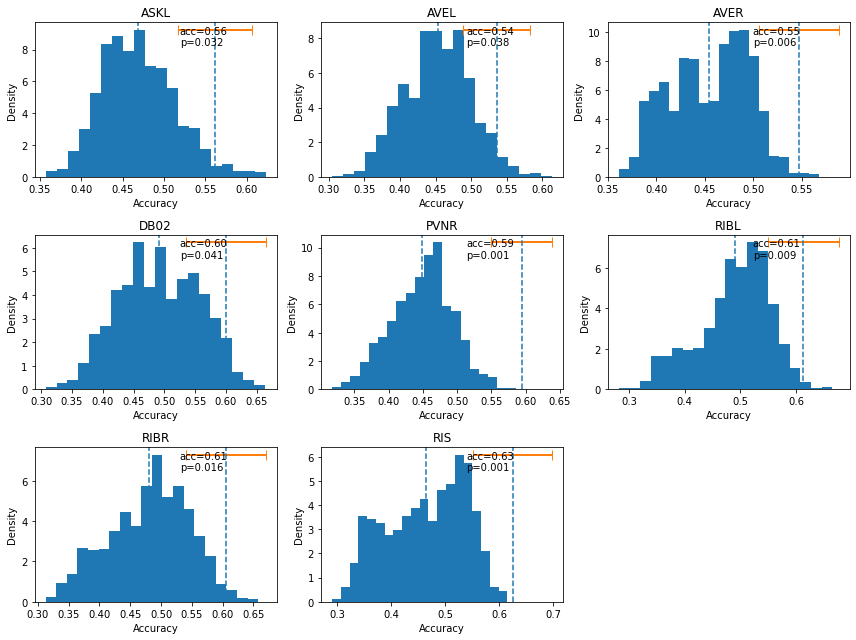

In [122]:
permutation_grid_significant(avg_df,o,1000)

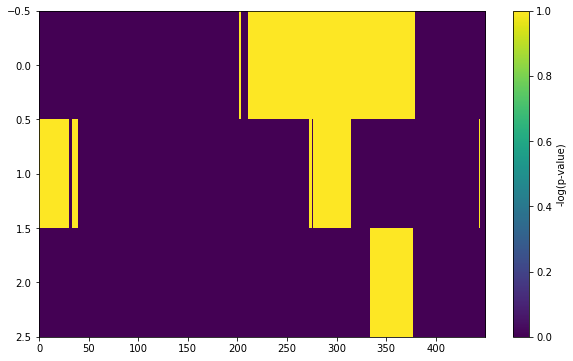

In [45]:
from scipy.stats import ttest_ind
import seaborn as sns
from statsmodels.stats.multitest import multipletests
# Assuming you have already created PLS1_df, PLS2_df, PLS3_df, PLS4_df, PLS5_df DataFrames

# List of DataFrame names
df_names = ['PLS1_df', 'PLS2_df', 'PLS3_df']

# Convert DataFrames to numeric type
for df_name in df_names:
    globals()[df_name] = globals()[df_name].apply(pd.to_numeric, errors='coerce')

# Initialize a dictionary to store p-values for each DataFrame
p_values_dict = {}

# Loop through each DataFrame
for df_name in df_names:
    df_ana = globals()[df_name]  # Access the DataFrame using its name

    # Select rows where the last column is 1 and 0
    df_1 = df_ana[df_ana.iloc[:, -1] == 1]
    df_0 = df_ana[df_ana.iloc[:, -1] == 0]

    # Initialize a dictionary to store p-values for this DataFrame
    df_p_values = {}

    # Perform t-test for each column except the last one
    for col in df_ana.columns[:-1]:
        t_stat, p_value = ttest_ind(df_1[col], df_0[col], equal_var=False)  # Use unequal variance
        df_p_values[col] = p_value

    # Store the p-values for this DataFrame
    p_values_dict[df_name] = df_p_values

# Create a DataFrame to store p-values
p_values_df = pd.DataFrame.from_dict(p_values_dict, orient='index')

# Apply Bonferroni correction by adjusting alpha
alpha_corrected = 0.05 / len(p_values_df.columns)

# Perform significance test using the corrected alpha
significant_results = p_values_df <= alpha_corrected

# Calculate the negative logarithm of p-values
neg_log_p_values = -np.log(p_values_df)

# Create a heatmap
plt.figure(figsize=(10, 6))
plt.imshow(significant_results,interpolation='None', aspect='auto')
# plt.imshow(p_values_df, cmap='jet', interpolation='None', aspect='auto', vmin=0, vmax=-np.log(alpha_corrected))
plt.colorbar(label='-log(p-value)')

# # Apply False Discovery Rate (FDR) correction
# rejected, p_values_corrected, _, _ = multipletests(p_values_df.values.flatten(), method='fdr_bh')
# # Reshape the corrected p-values
# p_values_corrected = p_values_corrected.reshape(p_values_df.shape)

# # Create a DataFrame with corrected p-values
# p_values_corrected_df = pd.DataFrame(p_values_corrected, index=p_values_df.index, columns=p_values_df.columns)

# # Create a heatmap with annotations
# plt.figure(figsize=(10, 6))
# plt.imshow(p_values_corrected_df <= 0.05,interpolation='None', aspect='auto')
# plt.title('Significance Test Results (FDR Correction)')
# plt.xlabel('Columns')
# plt.ylabel('DataFrames')
# plt.show()

In [40]:
after_pls_df

,PLS1,PLS2,PLS3,PLS4,PLS5,target,group,state
0,-1.893097,2.110908,-0.834136,0.542835,-0.8347,1.0,1.0,forward
1,-1.751525,2.194684,-0.696898,0.523927,-0.767646,1.0,1.0,forward
2,-1.700753,2.608792,-0.560021,0.506029,-0.728908,1.0,1.0,forward
3,-2.056156,2.855258,-0.842034,0.680765,-1.139842,1.0,1.0,forward
4,-2.275606,2.873087,-1.095281,0.677006,-1.38224,1.0,1.0,forward
...,...,...,...,...,...,...,...,...
52645,0.636097,-1.81634,-2.048825,3.161355,-0.479505,0.0,9.0,forward
52646,0.730504,-1.942734,-1.954519,2.930563,-0.546753,0.0,9.0,forward
52647,0.66474,-1.891033,-2.109331,2.73224,-0.524082,0.0,9.0,forward
52648,0.804694,-2.214259,-1.782042,2.767029,-0.291694,0.0,9.0,forward
